# Project Checkpoint 2: Research Question Formation

At this stage, you turn curiosity into clear research questions. Building on what you learned from your dataset and EDA, you’ll define questions that use course methods and stretch a bit further with at least one external data mining method. The goal is to ask questions that are interesting, meaningful, and doable, while also planning how you’ll study them.

## Checkpoint 2: RQ Formation 

Goal: Define research questions that require both course techniques and externally learned techniques.

Project Scope
Brief recap of dataset and EDA findings – Ex:
- Dataset: Retail transactions
- Course techniques: Frequent itemsets
- External techniques: Sequential pattern mining

Research Question Definition
Propose 3 research questions.
- At least 2 must use course techniques
- At least 1 must require an external technique

Ex RQs:
- RQ1: What frequent itemsets emerge under varying support thresholds?
- RQ2: How does confidence compare to lift when evaluating association rules?
- RQ3: Do sequential patterns reveal structure missed by unordered itemsets?

For each RQ:
- Data mining task type – Ex: Frequent itemset mining / sequential pattern mining
- Relevant algorithm(s) – Ex: Apriori (course), PrefixSpan (external)
- Evaluation criteria – Ex: Support, confidence, lift, interpretability

Additionally perform any additional EDA you need to in order to find some interesting questions you want to explore.

Motivation and Feasibility – Ex:
- Motivation: EDA shows long-tail and temporal clustering
- Non-triviality: Course techniques alone ignore ordering
- Feasibility: External algorithm learnable and implementable
- Risks: Computational cost, parameter sensitivity
- Additionally perform any additional EDA you need to in order to ensure the method is feasible.

Methodological Planning – Ex:
- Course algorithms: Apriori, FP-Growth
- External algorithms: PrefixSpan
- Evaluation: Pattern quality and diversity
- Baselines: High-support-only mining
- Additionally perform any initial method runs (e.g. testing out how packages work, etc.) you need to in order to ensure the methods are feasible.

Deliverables:
- Written RQ section
- RQ-to-method mapping table (course vs external)
- Method and metric plan

Deliverables: 
- A fully run Python notebook meeting the requirements specified here. 
- For every algorithmic decision you make, you must document WHY you made that decision. 
- You will be penalized for messiness – make sure your code is professional, well-explained, and well-documented.
- A collaboration declaration for the full notebook is required – this is the same as in the HWs, with one additional item: (1) Collaborators, (2) Web Sources, (3) AI Tools, (4) Citations for any papers that you used.

Rubric: 
- [50 pts] Strong/Professional: Correct and complete implementation of the task; Reasonable assumptions, stated or implied, and justified; Thoughtful handling of real-world data issues (missingness, noise, scale, duplicates, edge cases); Clear, concise explanations of what was done and why; Code is clean, readable, and well-structured, uses appropriate pandas, and would plausibly pass a professional code review; Tests meaningfully validate non-trivial behavior (not just "the code runs so it must be right").
- [25 pts] Partial/Developing: Core task mostly completed but with gaps, weak assumptions, or minor mistakes; Reasoning is shallow or mostly descriptive; Code works but is messy, repetitive, or fragile; Tests are superficial, incomplete, or poorly motivated.
- [0 pts] Minimal/Incorrect: Task is largely incorrect, missing, or misunderstands the goal; Little to no reasoning or justification; Code does not run or ignores constraints; No meaningful tests.

# Goal

```
To determine whether association rule mining captures meaningful product relationships or is primarily driven by product popularity, and to evaluate if incorporating temporal patterns improves prediction of future purchases.
```

The goal of this project checkpoint is to evaluate the effectiveness of association rule mining in the context of shopping retail data. While association rules are widely used in recommendation systems, they may often reflect the popularity of frequently purchased items rather than genuine relationships between products. This can lead to misleading insights and weak recommendations.

To address this, this project first investigates how these rules are formed and whether they are stable and meaningful. It then analyzes the extent to which popularity influences the discovered patterns. Finally, the project explores whether incorporating temporal information through sequential pattern mining can better capture real customer behavior and improve the ability to predict future purchases. My aim for this project is not to just to generate rules, but to understand what those rules truly represent and how useful they are in a real-world setting.

# Project Scope


### Dataset:
This project uses the Instacart Market Basket Analysis dataset, which contains approximately 3.4 million orders, over 32 million product-level interactions, and around 50K unique products. The dataset captures user purchase history across multiple orders, along with product hierarchy (aisles and departments) and temporal information such as order sequence and timing.

### Recap of Key Findings (Checkpoint 1):
- Basket sizes are moderate on average (around 9–10 items), but vary significantly across users and orders.
- Reorder behavior is strong (~55–60%), indicating that a large portion of purchases are habitual.
- Product frequency follows a long-tail distribution, with a small number of products dominating most transactions.
- The basket-product matrix is highly sparse, making pattern discovery sensitive to support thresholds.
- Reorder rates differ across product categories, with essential items showing higher repeat behavior.
- Temporal patterns (e.g., order time and frequency) suggest that purchases may follow structured behavior rather than being independent events.

### Course Techniques:
- Frequent itemset mining (Apriori / FP-Growth)
- Association rule mining using support, confidence, and lift

### External Technique:
- Sequential pattern mining (PrefixSpan) will be explored to incorporate the temporal ordering of purchases and capture patterns beyond unordered co-occurrence.

### Project Direction:
Building on these observations, the project focuses on evaluating whether association rules truly capture meaningful relationships between products or are largely influenced by product popularity. It further investigates whether incorporating temporal structure can better reflect real customer behavior and improve the predictability of future purchases.

In [45]:
# ! pip install mlxtend

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Data (update path if needed)
data_path = "./instacart/"

orders = pd.read_csv(data_path + "orders.csv")
order_products_prior = pd.read_csv(data_path + "order_products__prior.csv")
products = pd.read_csv(data_path + "products.csv")
aisles = pd.read_csv(data_path + "aisles.csv")
departments = pd.read_csv(data_path + "departments.csv")

# Basic Cleaning
# Keep only prior orders (for consistent historical behavior)
orders_prior = orders[orders['eval_set'] == 'prior']

# Merge orders with product interactions
order_products_prior = order_products_prior.merge(
    orders_prior[['order_id', 'user_id', 'order_number', 'days_since_prior_order']],
    on='order_id',
    how='inner'
)

# Merge product metadata
order_products_prior = order_products_prior.merge(
    products[['product_id', 'product_name', 'aisle_id', 'department_id']],
    on='product_id',
    how='left'
)

# Memory Optimization (important for large data)
order_products_prior['product_id'] = order_products_prior['product_id'].astype('int32')
order_products_prior['order_id'] = order_products_prior['order_id'].astype('int32')
order_products_prior['user_id'] = order_products_prior['user_id'].astype('int32')
order_products_prior['aisle_id'] = order_products_prior['aisle_id'].astype('int16')
order_products_prior['department_id'] = order_products_prior['department_id'].astype('int16')

# Quick Sanity Checks
print("Shape:", order_products_prior.shape)
print("Unique orders:", order_products_prior['order_id'].nunique())
print("Unique users:", order_products_prior['user_id'].nunique())
print("Unique products:", order_products_prior['product_id'].nunique())

order_products_prior.head()

Shape: (32434489, 10)
Unique orders: 3214874
Unique users: 206209
Unique products: 49677


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,days_since_prior_order,product_name,aisle_id,department_id
0,2,33120,1,1,202279,3,8.0,Organic Egg Whites,86,16
1,2,28985,2,1,202279,3,8.0,Michigan Organic Kale,83,4
2,2,9327,3,0,202279,3,8.0,Garlic Powder,104,13
3,2,45918,4,1,202279,3,8.0,Coconut Butter,19,13
4,2,30035,5,0,202279,3,8.0,Natural Sweetener,17,13


# Research Questions

NOTE: I tried to use the maximum amount of dataset wherever for this checkpoint that could be easily run on my device. In few places, I used a subset of the data or reduced to working on top X values or subset of the dataset due to my device hardware restrictions.

## RQ1 Reliability of Discovered Patterns

Main idea: How stable and reliable are the co-purchase patterns discovered from Instacart baskets under different mining settings? Can the generated metrics be used in real life or is it just for research purpose?

Before interpreting association rules as meaningful shopping knowledge, we need to know whether the discovered patterns are robust or whether they change drastically when the mining setup changes. So, it is about pattern reliability.

The Instacart dataset exhibits strong sparsity and a long-tail distribution of product frequencies (from Checkpoint 1), where a small number of products dominate a large portion of transactions. In such settings, frequent itemset mining can be highly sensitive to parameter choices, particularly the support threshold. If small changes in these parameters lead to significantly different patterns, then the resulting association rules may not be reliable enough to interpret or use for downstream applications such as recommendations. Therefore, before analyzing whether association rules capture meaningful relationships, it is important to evaluate how stable these patterns are under different mining settings. In this section, I will look into the effect of support thresholds and data representation on the discovered patterns and assess their stability.

Assumptions
- Transactions (baskets) are treated as independent observations.
- Product co-occurrence within a basket reflects meaningful user behavior.
- Changes in support thresholds and representation (product vs. aisle level) can significantly impact mined patterns.

Why this is my RQ?
- Checkpoint 1 showed that product frequencies are highly skewed and that only a small subset of products accounts for a large share of purchases
- It also showed that the basket-product matrix is extremely sparse and that most baskets contain only a small fraction of all products
- Because frequent itemset mining is sensitive to support thresholds, it is not obvious whether the rules produced are stable enough to support interpretation or recommendation

Sub-ideas under this RQ
- How sensitive are the discovered patterns to changes in support threshold?
- How does representation (product-level vs. aisle-level) affect pattern stability?
- How consistent are rule sets across different mining configurations?

Additional EDA under RQ1
- product frequency concentration
- basket size distribution
- sparsity summary

Algorithms
- Apriori or FP-Growth
- Association rule generation with confidence and lift
- Jaccard overlap for stability comparison

Outputs
- frequency concentration plot
- basket size plot
- itemset/rule count comparison chart
- top-rule summary table
- stability heatmap

===== Dataset Sparsity Summary =====
Number of Orders (Baskets): 3214874
Number of Unique Products: 49677
Total Interactions (Purchases): 32434489
Matrix Density: 0.00020309
Matrix Sparsity: 0.99979691


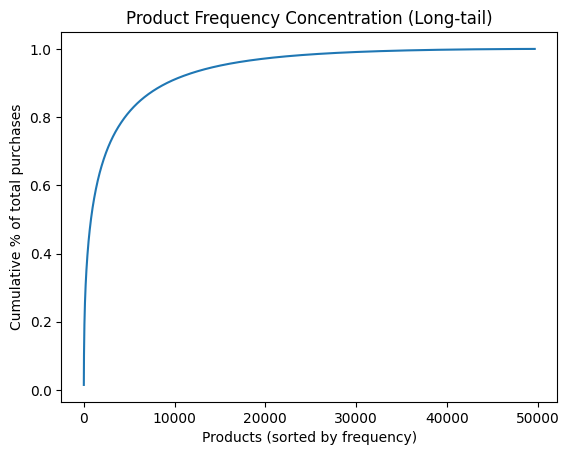


===== Product Frequency Concentration =====
Top 1% of products account for ~42.80% of all purchases
Top 5% of products account for ~69.85% of all purchases
Top 10% of products account for ~81.43% of all purchases


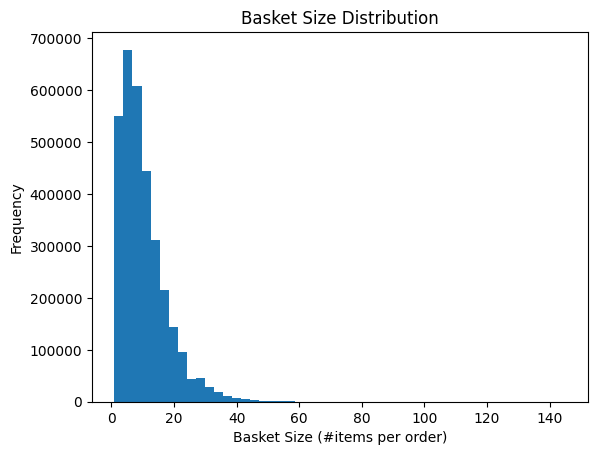


===== Basket Size Statistics =====
Average Basket Size: 10.09
Median Basket Size: 8.00
90th Percentile Basket Size: 20.00


In [47]:
# To understand whether association rules will be reliable, 
# we first examine how sparse the data is, how concentrated purchases are, 
# and how large baskets typically are.

# Basic Dataset Statistics (Sparsity)
num_orders = order_products_prior['order_id'].nunique()   # total unique baskets
num_products = order_products_prior['product_id'].nunique()  # total unique products
num_interactions = len(order_products_prior)  # total (order, product) pairs

# Density = how full the matrix is (very low → sparse data)
density = num_interactions / (num_orders * num_products)
print("===== Dataset Sparsity Summary =====")
print(f"Number of Orders (Baskets): {num_orders}")
print(f"Number of Unique Products: {num_products}")
print(f"Total Interactions (Purchases): {num_interactions}")
print(f"Matrix Density: {density:.8f}")
print(f"Matrix Sparsity: {1 - density:.8f}")


# Product Frequency Concentration (Long-tail Analysis)
# Count how many times each product appears across all baskets
product_counts = order_products_prior['product_id'].value_counts()

# Sort products by frequency (most frequent first)
product_counts = product_counts.sort_values(ascending=False)

# Compute cumulative contribution of products to total purchases
cum_perc = product_counts.cumsum() / product_counts.sum()

plt.figure()
plt.plot(cum_perc.values)
plt.xlabel("Products (sorted by frequency)")
plt.ylabel("Cumulative % of total purchases")
plt.title("Product Frequency Concentration (Long-tail)")
plt.show()

# Key statistics: how much top products dominate total purchases
n = len(product_counts)
top_1 = cum_perc.iloc[int(0.01 * n)]
top_5 = cum_perc.iloc[int(0.05 * n)]
top_10 = cum_perc.iloc[int(0.10 * n)]

print("\n===== Product Frequency Concentration =====")
print(f"Top 1% of products account for ~{top_1:.2%} of all purchases")
print(f"Top 5% of products account for ~{top_5:.2%} of all purchases")
print(f"Top 10% of products account for ~{top_10:.2%} of all purchases")


# Basket Size Distribution
# Compute number of items in each basket (order)
basket_sizes = order_products_prior.groupby('order_id').size()

plt.figure()
plt.hist(basket_sizes, bins=50)
plt.xlabel("Basket Size (#items per order)")
plt.ylabel("Frequency")
plt.title("Basket Size Distribution")
plt.show()

# Summary statistics of basket sizes
print("\n===== Basket Size Statistics =====")
print(f"Average Basket Size: {basket_sizes.mean():.2f}")
print(f"Median Basket Size: {basket_sizes.median():.2f}")
print(f"90th Percentile Basket Size: {basket_sizes.quantile(0.9):.2f}")

# No meaningful test cases could be added here.

The dataset is extremely sparse, meaning only a tiny fraction of all possible product–order combinations actually occur. This makes frequent itemset mining sensitive to parameters like support, since small changes can lead to very different patterns.

I also observed a strong long-tail distribution:
- A small fraction of products (top 1–10%) accounts for a large share of purchases
- Most products appear very infrequently

This suggests that discovered patterns may be dominated by a few popular items rather than truly meaningful relationships.

Looking at basket sizes:
- Most orders contain a moderate number of items (around 8–10 on average)
- This limits the number of co-occurrences per transaction

Together, these observations indicate that:
- The data structure itself can bias the patterns we discover
- The choice of support threshold will likely have a strong impact on results

Next, we explicitly test how changing support thresholds affects the number and stability of the patterns discovered.

In [48]:
# Here we convert the raw order data into transaction matrices 
# so we can compare pattern mining at the product level and the aisle level.

# We prepare two versions of the data:
# - product-level baskets using only the most frequent products
# - aisle-level baskets using broader category information

# Product-Level Transactions
from mlxtend.preprocessing import TransactionEncoder

# Restrict to top-N most frequently purchased products
top_n_products = 250
top_products = (order_products_prior["product_id"].value_counts().head(top_n_products).index)
order_products_top = order_products_prior[order_products_prior["product_id"].isin(top_products)].copy()

# Build product-level transactions:
# - group products by order
# - remove duplicates within the same basket
# - keep only baskets with at least 2 retained products
transactions_product = (order_products_top.groupby("order_id")["product_id"].apply(lambda x: sorted(set(x))))
transactions_product = transactions_product[transactions_product.apply(len) >= 2]
transactions_product = transactions_product.tolist()

# Encode baskets into a one-hot transaction matrix
te = TransactionEncoder()
te_array = te.fit(transactions_product).transform(transactions_product)
df_product = pd.DataFrame(te_array, columns=te.columns_)

# Coverage tells us what fraction of all product interactions is still represented
coverage = order_products_prior["product_id"].isin(top_products).mean()

# Basic checks
assert df_product.shape[1] <= top_n_products, "Product-level matrix has more columns than expected"
assert df_product.shape[0] == len(transactions_product), "Mismatch between product transactions and encoded matrix rows"
assert (df_product.sum(axis=1) >= 2).all(), "Some retained product baskets have fewer than 2 items"

print("===== Product-Level Transaction Matrix =====")
print(f"Matrix Shape: {df_product.shape}")
print(f"Number of Retained Products: {df_product.shape[1]}")
print(f"Number of Retained Baskets: {df_product.shape[0]}")
print(f"Coverage of Top {top_n_products} Products: {coverage:.2%} of all product interactions")


# Aisle-Level Transactions
# Build broader aisle-level baskets:
# - each basket contains unique aisle IDs instead of product IDs
# - keep only baskets with at least 2 distinct aisles
transactions_aisle = (order_products_prior.groupby("order_id")["aisle_id"].apply(lambda x: sorted(set(x))))
transactions_aisle = transactions_aisle[transactions_aisle.apply(len) >= 2].tolist()

# Encode aisle transactions into a one-hot matrix
te2 = TransactionEncoder()
te_array2 = te2.fit(transactions_aisle).transform(transactions_aisle)
df_aisle = pd.DataFrame(te_array2, columns=te2.columns_)

# Basic checks
assert df_aisle.shape[0] == len(transactions_aisle), "Mismatch between aisle transactions and encoded matrix rows"
assert (df_aisle.sum(axis=1) >= 2).all(), "Some retained aisle baskets have fewer than 2 items"

print("\n===== Aisle-Level Transaction Matrix =====")
print(f"Matrix Shape: {df_aisle.shape}")
print(f"Number of Retained Aisles: {df_aisle.shape[1]}")
print(f"Number of Retained Baskets: {df_aisle.shape[0]}")

===== Product-Level Transaction Matrix =====
Matrix Shape: (2032483, 250)
Number of Retained Products: 250
Number of Retained Baskets: 2032483
Coverage of Top 250 Products: 33.35% of all product interactions

===== Aisle-Level Transaction Matrix =====
Matrix Shape: (3014117, 134)
Number of Retained Aisles: 134
Number of Retained Baskets: 3014117


The full product-level matrix is too large and highly sparse due to the long-tail distribution of products. Most rare items would not appear under reasonable support thresholds, so I restrict the analysis to the most frequent products. This keeps the computation feasible while focusing on patterns that are more likely to be stable. Since RQ1 focuses on pattern stability, this simplification is acceptable as we are not trying to capture all rare itemsets.

We construct transactions at two levels:
- Product level: fine-grained but very sparse
- Aisle level: more aggregated, lower dimensional

This allows us to compare how representation affects the stability of discovered patterns.

Next, we run frequent itemset mining under different support thresholds.

In [49]:
# Here we test how sensitive the discovered patterns are by running frequent itemset mining 
# across different support thresholds.

# Frequent Itemset Mining (Product-Level)
# Goal:
# - Check if changing support leads to similar patterns or very different ones
# - Compare number of itemsets and rules across configurations

from mlxtend.frequent_patterns import fpgrowth, association_rules

# Different support thresholds to test sensitivity
support_values = [0.01, 0.02, 0.03, 0.05, 0.10]
product_results = []

# Run mining for different max pattern lengths
for max_len in [2, 3]:
    for min_sup in support_values:

        # Mine frequent itemsets using FP-Growth
        frequent_items = fpgrowth(df_product, min_support=min_sup, use_colnames=True, max_len=max_len)
        frequent_items["itemset_size"] = frequent_items["itemsets"].apply(len)

        # Generate association rules if itemsets exist
        if len(frequent_items) > 0:
            rules = association_rules(frequent_items, metric="confidence", min_threshold=0.1)

            # Keep only relevant columns for analysis
            if not rules.empty:
                rules = rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
            else:
                rules = pd.DataFrame(columns=["antecedents", "consequents", "support", "confidence", "lift"])
        else:
            rules = pd.DataFrame(columns=["antecedents", "consequents", "support", "confidence", "lift"])

        # Focus on meaningful itemsets (size >= 2)
        frequent_items_size_2plus = frequent_items[frequent_items["itemset_size"] >= 2].copy()

        # Basic checks
        assert len(frequent_items_size_2plus) <= len(frequent_items), "Filtered itemsets exceed total itemsets"
        if not rules.empty:
            assert set(rules.columns) == {"antecedents", "consequents", "support", "confidence", "lift"}, "Unexpected rule columns"

        # Store results for later comparison (e.g., stability analysis)
        product_results.append({
            "representation": "product",
            "max_len": max_len,
            "min_support": min_sup,
            "num_itemsets": len(frequent_items),
            "num_itemsets_size_2plus": len(frequent_items_size_2plus),
            "num_rules": len(rules),
            "frequent_itemsets": frequent_items,
            "rules": rules
        })

        # Print summary for each configuration
        print("===== Product-Level Mining =====")
        print(f"Max Length: {max_len} | Support: {min_sup}")
        print(f"Total Itemsets: {len(frequent_items)}")
        print(f"Itemsets (size >= 2): {len(frequent_items_size_2plus)}")
        print(f"Number of Rules: {len(rules)}\n")

    print("--------------------------------------------------\n")

===== Product-Level Mining =====
Max Length: 2 | Support: 0.01
Total Itemsets: 216
Itemsets (size >= 2): 47
Number of Rules: 65

===== Product-Level Mining =====
Max Length: 2 | Support: 0.02
Total Itemsets: 80
Itemsets (size >= 2): 9
Number of Rules: 16

===== Product-Level Mining =====
Max Length: 2 | Support: 0.03
Total Itemsets: 42
Itemsets (size >= 2): 2
Number of Rules: 4

===== Product-Level Mining =====
Max Length: 2 | Support: 0.05
Total Itemsets: 14
Itemsets (size >= 2): 0
Number of Rules: 0

===== Product-Level Mining =====
Max Length: 2 | Support: 0.1
Total Itemsets: 5
Itemsets (size >= 2): 0
Number of Rules: 0

--------------------------------------------------

===== Product-Level Mining =====
Max Length: 3 | Support: 0.01
Total Itemsets: 216
Itemsets (size >= 2): 47
Number of Rules: 65

===== Product-Level Mining =====
Max Length: 3 | Support: 0.02
Total Itemsets: 80
Itemsets (size >= 2): 9
Number of Rules: 16

===== Product-Level Mining =====
Max Length: 3 | Support: 0.

In [50]:
# Here we repeat the same mining process at the aisle level to compare how aggregation 
# affects pattern stability.

# Frequent Itemset Mining (Aisle-Level)
# Goal:
# - Compare with product-level results
# - Check if aggregated (aisle-level) data produces more stable patterns

aisle_results = []

for max_len in [2, 3]:
    for min_sup in support_values:

        # Mine frequent itemsets using FP-Growth
        frequent_items = fpgrowth(df_aisle, min_support=min_sup, use_colnames=True, max_len=max_len)
        frequent_items["itemset_size"] = frequent_items["itemsets"].apply(len)

        # Generate association rules if itemsets exist
        if len(frequent_items) > 0:
            rules = association_rules(frequent_items, metric="confidence", min_threshold=0.1)

            # Keep only relevant columns
            if not rules.empty:
                rules = rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
            else:
                rules = pd.DataFrame(columns=["antecedents", "consequents", "support", "confidence", "lift"])
        else:
            rules = pd.DataFrame(columns=["antecedents", "consequents", "support", "confidence", "lift"])

        # Focus on meaningful itemsets (size >= 2) for reporting
        frequent_items_size_2plus = frequent_items[frequent_items["itemset_size"] >= 2].copy()

        # Basic checks
        assert len(frequent_items_size_2plus) <= len(frequent_items), "Filtered itemsets exceed total itemsets"
        if not rules.empty:
            assert set(rules.columns) == {"antecedents", "consequents", "support", "confidence", "lift"}, "Unexpected rule columns"

        # Store results for later comparison
        aisle_results.append({
            "representation": "aisle",
            "max_len": max_len,
            "min_support": min_sup,
            "num_itemsets": len(frequent_items),
            "num_itemsets_size_2plus": len(frequent_items_size_2plus),
            "num_rules": len(rules),
            "frequent_itemsets": frequent_items,
            "rules": rules
        })

        # Print summary for each configuration
        print("===== Aisle-Level Mining =====")
        print(f"Max Length: {max_len} | Support: {min_sup}")
        print(f"Total Itemsets: {len(frequent_items)}")
        print(f"Itemsets (size >= 2): {len(frequent_items_size_2plus)}")
        print(f"Number of Rules: {len(rules)}\n")

    print("--------------------------------------------------\n")

===== Aisle-Level Mining =====
Max Length: 2 | Support: 0.01
Total Itemsets: 990
Itemsets (size >= 2): 893
Number of Rules: 1362

===== Aisle-Level Mining =====
Max Length: 2 | Support: 0.02
Total Itemsets: 447
Itemsets (size >= 2): 368
Number of Rules: 601

===== Aisle-Level Mining =====
Max Length: 2 | Support: 0.03
Total Itemsets: 264
Itemsets (size >= 2): 202
Number of Rules: 346

===== Aisle-Level Mining =====
Max Length: 2 | Support: 0.05
Total Itemsets: 130
Itemsets (size >= 2): 81
Number of Rules: 153

===== Aisle-Level Mining =====
Max Length: 2 | Support: 0.1
Total Itemsets: 36
Itemsets (size >= 2): 19
Number of Rules: 38

--------------------------------------------------

===== Aisle-Level Mining =====
Max Length: 3 | Support: 0.01
Total Itemsets: 2344
Itemsets (size >= 2): 2247
Number of Rules: 6763

===== Aisle-Level Mining =====
Max Length: 3 | Support: 0.02
Total Itemsets: 797
Itemsets (size >= 2): 718
Number of Rules: 2178

===== Aisle-Level Mining =====
Max Length: 3 

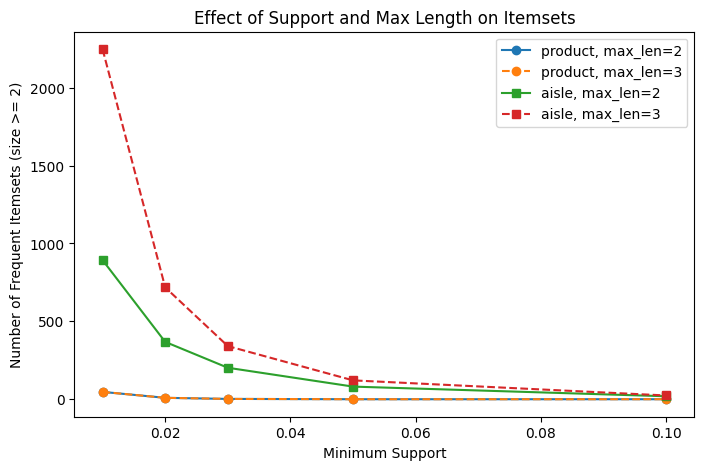

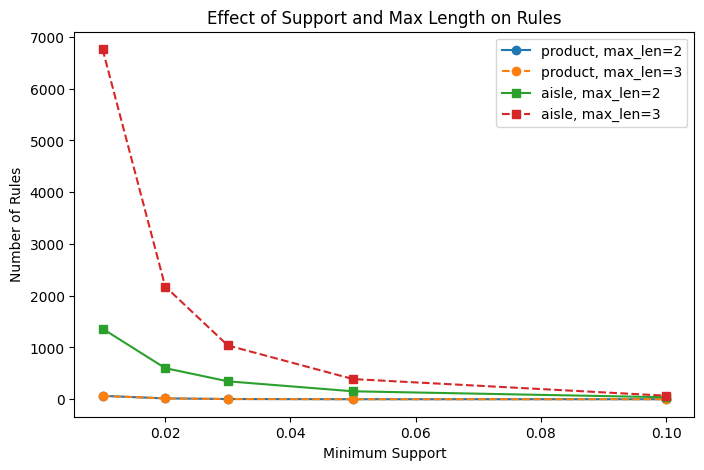

In [51]:
# Plots
results_df = pd.DataFrame(product_results + aisle_results)

# Quick check to make sure max_len was stored in the mining results
assert "max_len" in results_df.columns, "Column 'max_len' is missing. Add 'max_len': max_len in both mining result dictionaries and rerun those cells."

style_map = {
    ("product", 2): "-o",
    ("product", 3): "--o",
    ("aisle", 2): "-s",
    ("aisle", 3): "--s"
}

# Plot 1: Frequent itemsets
plt.figure(figsize=(8, 5))

for rep in ["product", "aisle"]:
    for max_len in [2, 3]:
        subset = results_df[(results_df["representation"] == rep) &
                            (results_df["max_len"] == max_len)].sort_values("min_support")

        plt.plot(subset["min_support"], subset["num_itemsets_size_2plus"],
            style_map[(rep, max_len)], label=f"{rep}, max_len={max_len}")

plt.xlabel("Minimum Support")
plt.ylabel("Number of Frequent Itemsets (size >= 2)")
plt.title("Effect of Support and Max Length on Itemsets")
plt.legend()
plt.show()


# Plot 2: Association rules
plt.figure(figsize=(8, 5))

for rep in ["product", "aisle"]:
    for max_len in [2, 3]:
        subset = results_df[(results_df["representation"] == rep) &
                            (results_df["max_len"] == max_len)].sort_values("min_support")

        plt.plot(
            subset["min_support"], subset["num_rules"],
            style_map[(rep, max_len)], label=f"{rep}, max_len={max_len}")

plt.xlabel("Minimum Support")
plt.ylabel("Number of Rules")
plt.title("Effect of Support and Max Length on Rules")
plt.legend()
plt.show()

To evaluate reliability, we run frequent itemset mining across different support thresholds for both product and aisle representations.

From the plots:
- The number of itemsets and rules drops sharply as support increases
- Aisle-level mining produces many more patterns than product-level
- Product-level patterns disappear quickly due to sparsity

This suggests that:
- Product-level patterns are highly sensitive to support
- Aisle-level patterns are more stable due to aggregation

Overall, the results show that pattern discovery depends strongly on support and representation, motivating a direct stability comparison next.

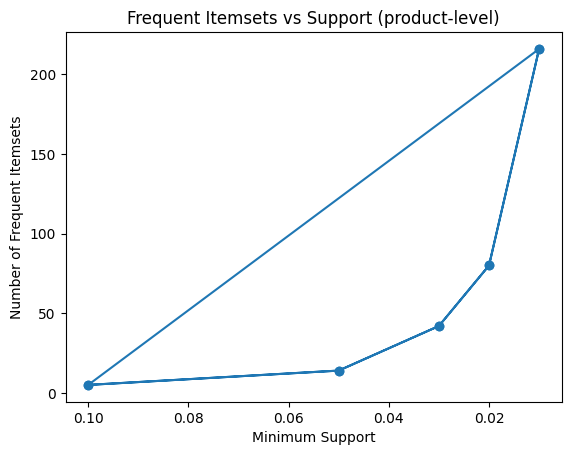

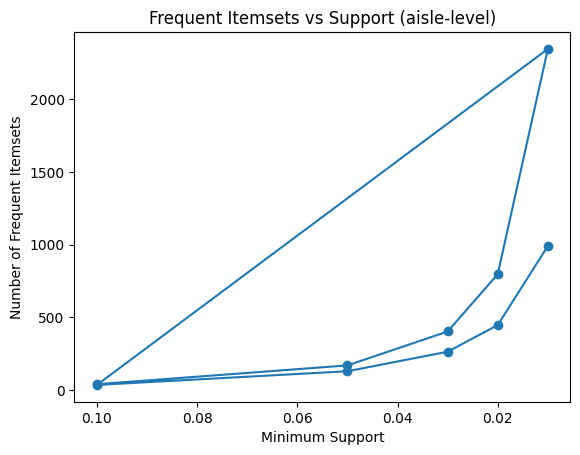

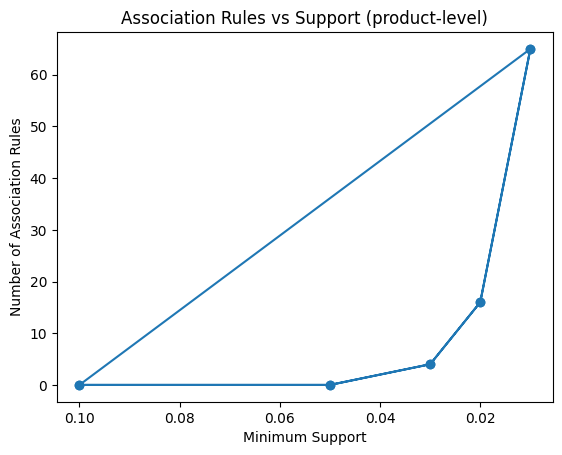

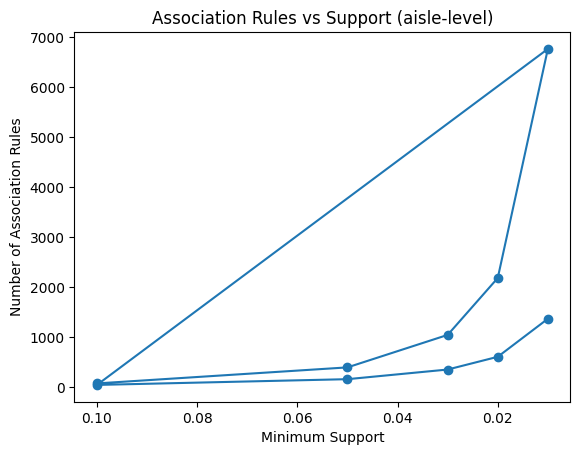

In [52]:
# Summarize Pattern Counts
# Build Summary Table
summary_rows = []

for result in product_results + aisle_results:
    summary_rows.append({
        "representation": result["representation"],
        "min_support": result["min_support"],
        "num_itemsets": result["num_itemsets"],
        "num_itemsets_size_2plus": result["num_itemsets_size_2plus"],
        "num_rules": result["num_rules"]
    })

rq1_summary = pd.DataFrame(summary_rows)
rq1_summary

import matplotlib.pyplot as plt

# Plot number of itemsets
for rep in ["product", "aisle"]:
    subset = rq1_summary[rq1_summary["representation"] == rep]
    plt.figure()
    plt.plot(subset["min_support"], subset["num_itemsets"], marker="o")
    plt.xlabel("Minimum Support")
    plt.ylabel("Number of Frequent Itemsets")
    plt.title(f"Frequent Itemsets vs Support ({rep}-level)")
    plt.gca().invert_xaxis()
    plt.show()

# Plot number of rules
for rep in ["product", "aisle"]:
    subset = rq1_summary[rq1_summary["representation"] == rep]
    plt.figure()
    plt.plot(subset["min_support"], subset["num_rules"], marker="o")
    plt.xlabel("Minimum Support")
    plt.ylabel("Number of Association Rules")
    plt.title(f"Association Rules vs Support ({rep}-level)")
    plt.gca().invert_xaxis()
    plt.show()

As expected, lowering the support threshold increases the number of itemsets and rules, often sharply. This shows that the pattern space is highly sensitive to support, and small changes can lead to very different outputs.

Comparing representations:
- Product-level patterns remain limited due to sparsity
- Aisle-level patterns grow much larger, especially at low support

This suggests that both support choice and representation strongly affect the patterns discovered, reinforcing the need to evaluate stability explicitly.

In [53]:
# Inspect Top Rules
# Show only a few representative support thresholds to keep the output readable.

product_name_map = products.set_index("product_id")["product_name"].to_dict()
aisle_name_map = aisles.set_index("aisle_id")["aisle"].to_dict()

def format_rule_table_with_names(rules_df, name_map, top_n=10, sort_by="lift"):
    if rules_df.empty:
        return pd.DataFrame(columns=["antecedents", "consequents", "support", "confidence", "lift"])
    
    def convert_itemset(itemset):
        return ", ".join([str(name_map.get(x, x)) for x in sorted(list(itemset))])

    temp = rules_df.copy()
    temp["antecedents"] = temp["antecedents"].apply(convert_itemset)
    temp["consequents"] = temp["consequents"].apply(convert_itemset)
    temp = temp.sort_values(sort_by, ascending=False).head(top_n)
    return temp.reset_index(drop=True)

selected_supports = [0.03]  # Example: only show rules for this support threshold
# selected_supports = [0.01, 0.03, 0.10]  # Uncomment to show rules for multiple support thresholds

print("===== Top Product-Level Rules (Representative Supports) =====")
for result in product_results:
    if result["min_support"] in selected_supports:
        print(f"\nSupport = {result['min_support']}")
        display(format_rule_table_with_names(
            result["rules"],
            product_name_map,
            top_n=5,
            sort_by="lift"
        ))

print("\n===== Top Aisle-Level Rules (Representative Supports) =====")
for result in aisle_results:
    if result["min_support"] in selected_supports:
        print(f"\nSupport = {result['min_support']}")
        display(format_rule_table_with_names(
            result["rules"],
            aisle_name_map,
            top_n=5,
            sort_by="lift"
        ))

===== Top Product-Level Rules (Representative Supports) =====

Support = 0.03


,antecedents,consequents,support,confidence,lift
0,Bag of Organic Bananas,Organic Hass Avocado,0.030672,0.178315,1.755112
1,Organic Hass Avocado,Bag of Organic Bananas,0.030672,0.301901,1.755112
2,Bag of Organic Bananas,Organic Strawberries,0.030322,0.176275,1.413126
3,Organic Strawberries,Bag of Organic Bananas,0.030322,0.243075,1.413126



Support = 0.03


,antecedents,consequents,support,confidence,lift
0,Bag of Organic Bananas,Organic Hass Avocado,0.030672,0.178315,1.755112
1,Organic Hass Avocado,Bag of Organic Bananas,0.030672,0.301901,1.755112
2,Bag of Organic Bananas,Organic Strawberries,0.030322,0.176275,1.413126
3,Organic Strawberries,Bag of Organic Bananas,0.030322,0.243075,1.413126



===== Top Aisle-Level Rules (Representative Supports) =====

Support = 0.03


,antecedents,consequents,support,confidence,lift
0,chips pretzels,fresh dips tapenades,0.037341,0.210320,2.020737
1,fresh dips tapenades,chips pretzels,0.037341,0.358765,2.020737
2,lunch meat,bread,0.036101,0.326774,1.876712
3,bread,lunch meat,0.036101,0.207336,1.876712
4,fresh herbs,fresh vegetables,0.084119,0.846417,1.799968



Support = 0.03


,antecedents,consequents,support,confidence,lift
0,fresh dips tapenades,chips pretzels,0.037341,0.358765,2.020737
1,chips pretzels,fresh dips tapenades,0.037341,0.210320,2.020737
2,"fresh vegetables, packaged vegetables fruits",fresh herbs,0.049967,0.199813,2.010541
3,fresh herbs,"fresh vegetables, packaged vegetables fruits",0.049967,0.502776,2.010541
4,fresh herbs,"fresh fruits, fresh vegetables",0.065663,0.660712,1.949426


Inspecting the top rules gives a qualitative view of how the actual patterns change across settings, beyond just counts. We observe that:

- Some product-level rules, such as “Bag of Organic Bananas → Organic Hass Avocado” and “Organic Strawberries ↔ Bag of Organic Bananas”, appear consistently, suggesting robustness
- At the aisle level, patterns like “chips pretzels ↔ fresh dips tapenades” and “bread ↔ lunch meat” are repeatedly observed
- Other rules (e.g., involving broader vegetable combinations) appear only under certain thresholds, indicating sensitivity

This shows that while a few strong, intuitive patterns persist, many rules depend on the mining setup. Since counts alone do not capture this behavior, we now directly measure rule overlap across settings to quantify stability.

#### Key question: Are the discovered rules actually stable across different settings?

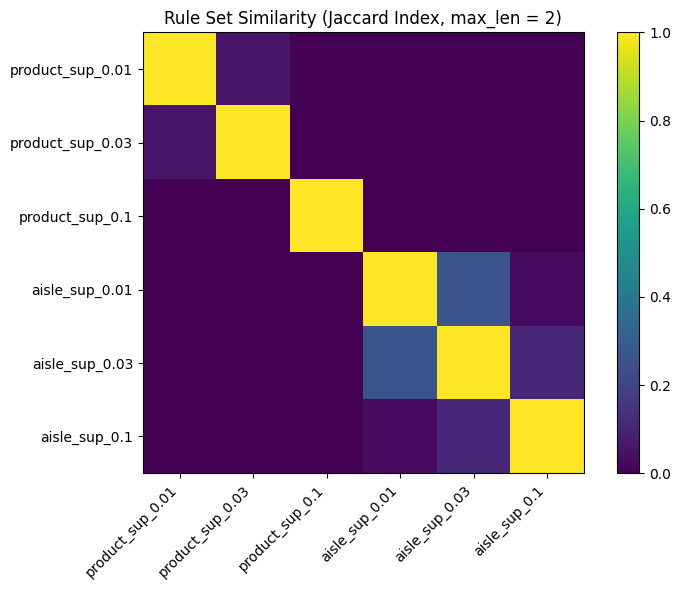

In [54]:
# We compare only max_len = 2 rule sets because pairwise rules are easier to interpret 
# and give a cleaner view of stability across support thresholds.

# Rule Stability Analysis
def rules_to_tuples(rules_df):
    if rules_df.empty:
        return set()
    
    return set([
        (frozenset(row["antecedents"]), frozenset(row["consequents"]))
        for _, row in rules_df.iterrows()
    ])

def jaccard_similarity(set1, set2):
    if len(set1) == 0 and len(set2) == 0:
        return 1.0
    if len(set1.union(set2)) == 0:
        return 0.0
    return len(set1.intersection(set2)) / len(set1.union(set2))

# Build rule sets only for max_len = 2
# Use fewer support values for cleaner visualization
selected_supports = [0.01, 0.03, 0.10]

rule_sets = {}

for result in product_results:
    if result["max_len"] == 2 and result["min_support"] in selected_supports:
        key = f"product_sup_{result['min_support']}"
        rule_sets[key] = rules_to_tuples(result["rules"])

for result in aisle_results:
    if result["max_len"] == 2 and result["min_support"] in selected_supports:
        key = f"aisle_sup_{result['min_support']}"
        rule_sets[key] = rules_to_tuples(result["rules"])

# Compute similarity matrix
keys = list(rule_sets.keys())
similarity_matrix = pd.DataFrame(index=keys, columns=keys)

for k1 in keys:
    for k2 in keys:
        similarity_matrix.loc[k1, k2] = jaccard_similarity(rule_sets[k1], rule_sets[k2])

similarity_matrix = similarity_matrix.astype(float)
similarity_matrix

# Heatmap visualization
plt.figure(figsize=(8, 6))
plt.imshow(similarity_matrix, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(keys)), keys, rotation=45, ha="right")
plt.yticks(range(len(keys)), keys)
plt.title("Rule Set Similarity (Jaccard Index, max_len = 2)")
plt.tight_layout()
plt.show()

To evaluate stability, I compared rule sets across support thresholds and representations using Jaccard similarity. From the heatmap:
- Product-level rule sets show near-zero overlap across supports, indicating high sensitivity
- Aisle-level rule sets show moderate overlap, especially between nearby thresholds (e.g., 0.01 vs 0.03)
- Cross comparisons between product and aisle are close to zero, showing they capture very different patterns

This suggests that:
- Product-level patterns are unstable and highly dependent on support
- Aisle-level patterns are more consistent due to aggregation

### Conclusion RQ1

The results indicate that patterns discovered through frequent itemset and association rule mining are highly sensitive to both the support threshold and the level of data representation. At the product level, even small changes in support lead to large differences in both the number and composition of rules, indicating low stability.

In contrast, aisle-level representations produce more consistent rule sets, suggesting that aggregation reduces sparsity and improves robustness. Overall, association rule mining on this dataset is not inherently stable. Reliable patterns require careful choices of support thresholds and appropriate data representation.

```
On my honor, I declare the following resources for RQ1:

1. Collaborators:  
- None.

2. Web Sources:  
- Instacart Market Basket Analysis Dataset: https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis  
- Kaggle dataset documentation pages were referenced to understand relational schema and usage constraints.

3. AI Tools:  
- I used chatGPT extensively to provide better readability on the code and visualizations but the overall ideas, questions and prompts provided to the GPT were my own ideas.
- Used some ideas from ChatGPT to generate some EDAs

4. Conference papers:
- None.
```

## RQ2 Temporal Variation in Co-Purchase Patterns

Main idea: How do co-purchase patterns vary across day of week and time of day, and how different are these temporal patterns from global (non-temporal) patterns?

While RQ1 looked into global co-purchase patterns, it assumes that customer behavior is consistent across all shopping contexts. In practice, shopping behavior may vary depending on when customers place orders. For example, weekday baskets may differ from weekend baskets, and morning purchases may reflect different needs compared to evening orders. If such temporal variation exists, then global association rules may average over different behaviors and fail to capture context-specific patterns. Therefore, this next question focuses on identifying whether co-purchase patterns remain stable across time or vary based on temporal factors.

Assumptions:
- Transactions can be meaningfully segmented by day of week and time of day
- Shopping behavior differs across temporal contexts
- Co-purchase patterns within each segment reflect context-specific behavior

Why this is my RQ?
- Findings from RQ1 motivate this question:
- Global patterns are sensitive to mining parameters and representation
- Stable global rules may still hide underlying variation across contexts
- Aggregated analysis may mask time-specific behavior

Thus, it is important to evaluate whether global patterns hold consistently across time or differ significantly across temporal segments.

Sub-questions
- How do co-purchase patterns differ across weekdays vs weekends?
- How do patterns vary across time of day (morning, afternoon, evening)?
- How different are temporal rule sets compared to global rule sets?

Additional EDA under RQ2
- Order distribution across day of week
- Order distribution across time of day
- Basket size variation across temporal segments

Methods
- Segment transactions by day of week and time of day
- Apply FP-Growth within each segment
- Generate association rules using support, confidence, and lift
- Compare temporal rule sets with global rules

Expected Outputs
- Order distribution plots (day and time)
- Segment-wise rule counts
- Top rules per segment
- Comparison of temporal vs global rules
- Rule overlap (Jaccard similarity) between segments

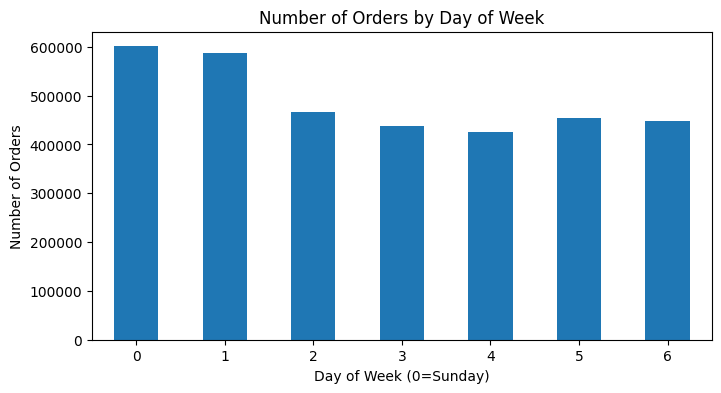

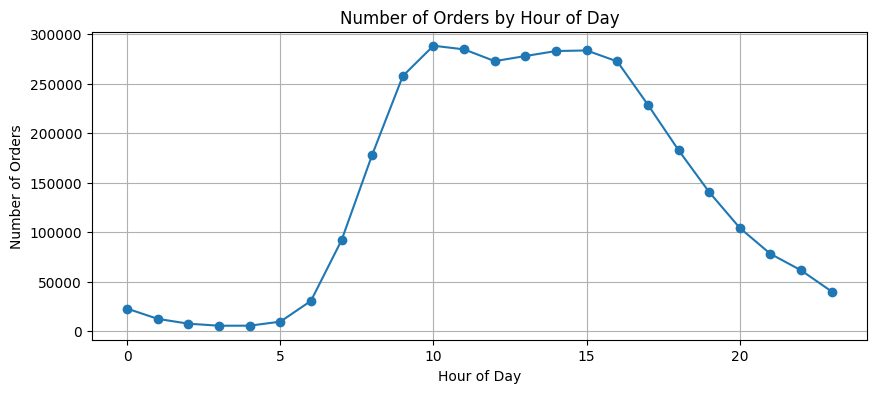

In [55]:
# To understand temporal shopping behavior, 
# we first examine how orders are distributed across days of the week and hours of the day.

# Orders distribution by day of week
dow_counts = orders['order_dow'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
dow_counts.plot(kind='bar')
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week (0=Sunday)")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

# Orders by hour of day
hour_counts = orders['order_hour_of_day'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
hour_counts.plot(kind='line', marker='o')
plt.title("Number of Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()

In [56]:
# We segment orders into coarse time-of-day groups,
# so we can compare shopping patterns across different daily contexts.

# Create time-of-day segments
def get_time_segment(hour):
    if 5 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 16:
        return "Afternoon"
    elif 17 <= hour <= 21:
        return "Evening"
    else:
        return "Night"

orders['time_segment'] = orders['order_hour_of_day'].apply(get_time_segment)

# Quick sanity check: mapping looks correct
print("===== Sample Mapping (Hour → Time Segment) =====")
print(orders[['order_hour_of_day', 'time_segment']].head())

# Distribution of orders across segments
print("\n===== Orders per Time Segment =====")
print(orders['time_segment'].value_counts())

===== Sample Mapping (Hour → Time Segment) =====
   order_hour_of_day time_segment
0                  8      Morning
1                  7      Morning
2                 12    Afternoon
3                  7      Morning
4                 15    Afternoon

===== Orders per Time Segment =====
time_segment
Afternoon    1390074
Morning      1141125
Evening       734677
Night         155207
Name: count, dtype: int64


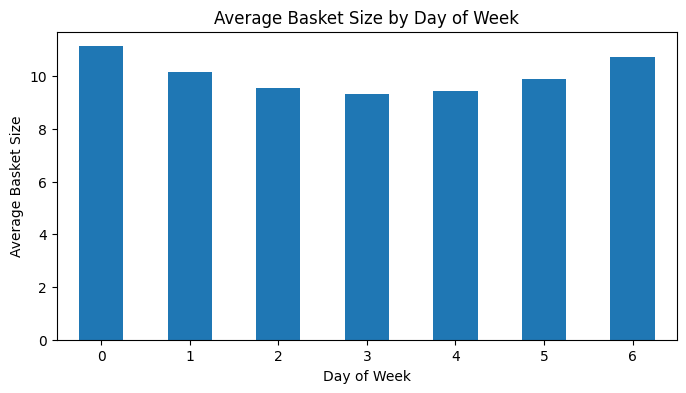

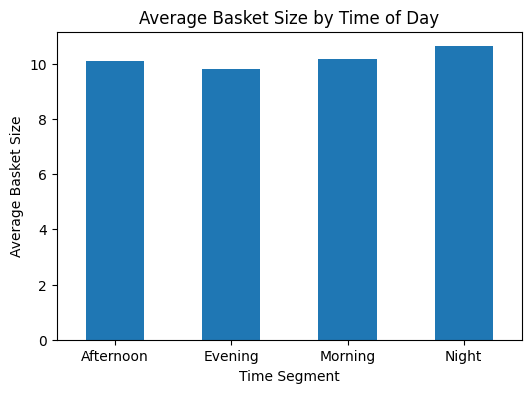

In [57]:
# To understand how shopping behavior varies across time, 
# we examine how basket sizes differ by day of week and time of day.

# Basket Size Computation
basket_sizes = (
    order_products_prior.groupby('order_id')['product_id']
    .count()
    .reset_index(name='basket_size')
)

# Merge with orders
basket_orders = basket_sizes.merge(
    orders[['order_id', 'order_dow', 'time_segment']],
    on='order_id',
    how='left'
)

# Average basket size by day
avg_basket_dow = basket_orders.groupby('order_dow')['basket_size'].mean()

plt.figure(figsize=(8, 4))
avg_basket_dow.plot(kind='bar')
plt.title("Average Basket Size by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Basket Size")
plt.xticks(rotation=0)
plt.show()

# Average basket size by time segment
avg_basket_time = basket_orders.groupby('time_segment')['basket_size'].mean()

plt.figure(figsize=(6, 4))
avg_basket_time.plot(kind='bar')
plt.title("Average Basket Size by Time of Day")
plt.xlabel("Time Segment")
plt.ylabel("Average Basket Size")
plt.xticks(rotation=0)
plt.show()

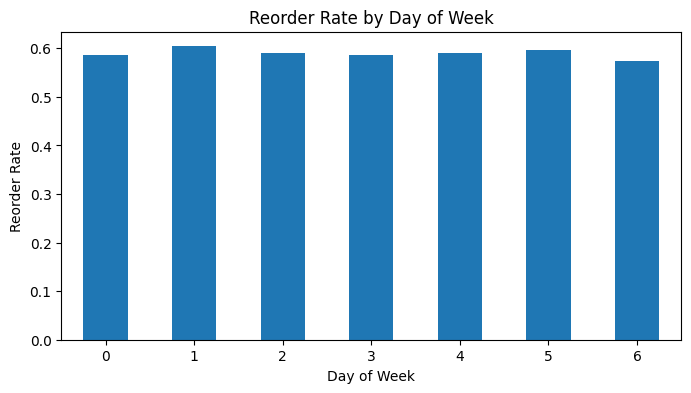

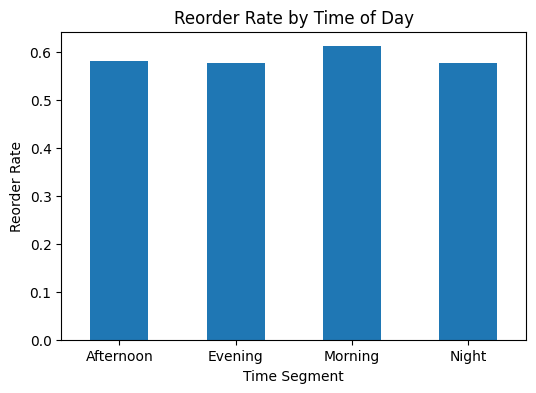

In [58]:
# To understand whether repeat purchasing behavior varies across time, 
# we analyze reorder rates by day of week and time of day.

# Reorder rate analysis
reorder_df = order_products_prior.merge(orders[['order_id', 'order_dow', 'time_segment']], on='order_id', how='left')

# Reorder rate by day
reorder_by_day = reorder_df.groupby('order_dow')['reordered'].mean()

plt.figure(figsize=(8, 4))
reorder_by_day.plot(kind='bar')
plt.title("Reorder Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Reorder Rate")
plt.xticks(rotation=0)
plt.show()

# Reorder rate by time segment
reorder_by_time = reorder_df.groupby('time_segment')['reordered'].mean()

plt.figure(figsize=(6, 4))
reorder_by_time.plot(kind='bar')
plt.title("Reorder Rate by Time of Day")
plt.xlabel("Time Segment")
plt.ylabel("Reorder Rate")
plt.xticks(rotation=0)
plt.show()

The distribution of orders across days and hours shows that shopping activity is not uniform, with clear peaks on certain days and during daytime hours. To simplify analysis, hours are grouped into broader time segments (morning, afternoon, evening, night), which capture meaningful differences while avoiding sparsity.

We observe that:
- Basket size varies slightly across time, with some segments (e.g., night) having larger baskets
- Reorder rates differ across segments, with morning showing higher reorder behavior, suggesting more routine purchases

Overall, these patterns indicate that shopping behavior is temporally structured. Ignoring time would average over these differences, potentially hiding important context-specific co-purchase patterns.

In [59]:
# Before comparing temporal patterns, we first mine a global aisle-level baseline 
# so we can see how time-specific rules differ from the overall shopping behavior.

# Build global aisle transactions
# Group each order into a set of unique aisle IDs
# Keep only baskets with at least 2 aisles
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

min_support_rq2 = 0.01

# Build aisle-level transactions (global)
# Keep only baskets with >= 2 items
transactions_aisle_global = (
    order_products_prior.groupby("order_id")["aisle_id"]
    .apply(lambda x: sorted(set(x)))
)
transactions_aisle_global = transactions_aisle_global[transactions_aisle_global.apply(len) >= 2].tolist()

print("===== Global Aisle Transactions =====")
print(f"Total Global Baskets: {len(transactions_aisle_global)}")

# Encode Global Transactions
te = TransactionEncoder()
te_array = te.fit(transactions_aisle_global).transform(transactions_aisle_global)
df_aisle_global = pd.DataFrame(te_array, columns=te.columns_)

print(f"Global Aisle Matrix Shape: {df_aisle_global.shape}")

# Mine Global Frequent Itemsets
frequent_items_global = fpgrowth(
    df_aisle_global,
    min_support=min_support_rq2,
    use_colnames=True,
    max_len=2
)
frequent_items_global["itemset_size"] = frequent_items_global["itemsets"].apply(len)

print("\n===== Global Frequent Itemsets =====")
print(f"Total Frequent Itemsets: {len(frequent_items_global)}")
print(f"Frequent Itemsets (size >= 2): {len(frequent_items_global[frequent_items_global['itemset_size'] >= 2])}")

===== Global Aisle Transactions =====
Total Global Baskets: 3014117
Global Aisle Matrix Shape: (3014117, 134)

===== Global Frequent Itemsets =====
Total Frequent Itemsets: 990
Frequent Itemsets (size >= 2): 893


The global aisle-level analysis produces a large number of frequent itemsets (nearly 900 pairwise patterns at 1% support), indicating that there are many consistent co-purchase relationships when all transactions are considered together. However, this global view aggregates all shopping behavior across different days and times. Given the temporal variation observed earlier (in order volume, basket size, and reorder rates), it is likely that these global patterns combine multiple underlying behaviors.

This motivates the next step, instead of relying on global rules, we analyze co-purchase patterns within temporal segments to identify context-specific associations and compare them with the global baseline.

In [60]:
# We generate global association rules and map them to readable names to serve as 
# a baseline for comparison with temporal patterns.

# Generate association rules
rules_global = association_rules(frequent_items_global, metric="confidence", min_threshold=0.1)
if not rules_global.empty:
    rules_global = rules_global[["antecedents", "consequents", "support", "confidence", "lift"]].copy()

# Sort by lift
top_rules_global = rules_global.sort_values(by="lift", ascending=False).head(10)

# Map aisle IDs to readable names
aisle_name_map = aisles.set_index("aisle_id")["aisle"].to_dict()

def convert_itemset(itemset):
    return ", ".join([str(aisle_name_map.get(x, x)) for x in sorted(list(itemset))])

top_rules_global_named = top_rules_global.copy()
top_rules_global_named["antecedents"] = top_rules_global_named["antecedents"].apply(convert_itemset)
top_rules_global_named["consequents"] = top_rules_global_named["consequents"].apply(convert_itemset)

print("Total global rules:", len(rules_global))
print("\nTop global rules with readable names:")
display(top_rules_global_named)

Total global rules: 1362

Top global rules with readable names:


,antecedents,consequents,support,confidence,lift
1210,pasta sauce,dry pasta,0.020736,0.314253,4.177906
1211,dry pasta,pasta sauce,0.020736,0.275685,4.177906
653,canned meals beans,canned jarred vegetables,0.019473,0.262642,3.354979
652,canned jarred vegetables,canned meals beans,0.019473,0.248752,3.354979
1164,frozen pizza,frozen meals,0.010672,0.233277,2.977457
1163,frozen meals,frozen pizza,0.010672,0.136215,2.977457
127,spices seasonings,canned jarred vegetables,0.011548,0.208731,2.666322
128,canned jarred vegetables,spices seasonings,0.011548,0.147518,2.666322
1181,soup broth bouillon,canned jarred vegetables,0.017629,0.199170,2.544190
1180,canned jarred vegetables,soup broth bouillon,0.017629,0.225188,2.544190


We first mined global aisle-level association rules to create a baseline for overall shopping behavior. These rules capture co-purchase patterns across the full dataset without considering temporal context.

The top global rules show strong aisle-level relationships such as pasta sauce ↔ dry pasta and frozen pizza ↔ frozen meals. This baseline helps us compare whether temporal segments follow the same broad patterns or reveal more context-specific associations.

In [61]:
# We now mine aisle-level rules within each day and time segment so we can compare temporal patterns against the global baseline.

# Generate aisle-level association rules for a subset of orders.
def mine_aisle_rules(order_subset, min_support=0.01):

    # Keep only products that belong to the selected subset of orders
    filtered_products = order_products_prior[order_products_prior["order_id"].isin(order_subset["order_id"])]

    # Build aisle-level transactions by grouping unique aisles within each order
    transactions = (filtered_products.groupby("order_id")["aisle_id"].apply(lambda x: sorted(set(x))))

    # Remove baskets that are too small to form co-purchase rules
    transactions = transactions[transactions.apply(len) >= 2].tolist()

    if len(transactions) == 0:
        return {"frequent_itemsets": pd.DataFrame(), "rules": pd.DataFrame()}

    # Encode transactions into a one-hot matrix
    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    df = pd.DataFrame(te_array, columns=te.columns_)

    # Mine frequent itemsets
    frequent_items = fpgrowth(df, min_support=min_support, use_colnames=True, max_len=2)
    if frequent_items.empty:
        return {"frequent_itemsets": frequent_items, "rules": pd.DataFrame()}

    # Generate association rules
    rules = association_rules(frequent_items, metric="confidence", min_threshold=0.1)
    if not rules.empty:
        rules = rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
    else:
        rules = pd.DataFrame()

    return {"frequent_itemsets": frequent_items, "rules": rules}

# Day-wise Mining
day_results = {}
for day in sorted(orders["order_dow"].unique()):
    day_orders = orders[orders["order_dow"] == day]
    result = mine_aisle_rules(day_orders, min_support=min_support_rq2)
    day_results[day] = result

    print(f"Day {day}: {len(result['rules'])} rules")

print("\n--------------------------------------------------\n")
# Time-of-Day Mining
time_results = {}
for segment in orders["time_segment"].unique():
    seg_orders = orders[orders["time_segment"] == segment]
    result = mine_aisle_rules(seg_orders, min_support=min_support_rq2)
    time_results[segment] = result

    print(f"{segment}: {len(result['rules'])} rules")

Day 0: 1620 rules
Day 1: 1317 rules
Day 2: 1193 rules
Day 3: 1149 rules
Day 4: 1182 rules
Day 5: 1327 rules
Day 6: 1571 rules

--------------------------------------------------

Morning: 1391 rules
Afternoon: 1373 rules
Evening: 1210 rules
Night: 1503 rules


Day-of-Week Pattern Extraction
- Association rules mined across days show noticeable variation in rule counts (e.g., Day 0: 1620 vs Day 1: 1317), indicating that co-purchase behavior differs across the week. Using a consistent setup ensures these differences reflect temporal effects rather than modeling choices.

Time-of-Day Pattern Extraction
- Similarly, rule counts vary across time segments (Morning: 1391, Afternoon: 1373, Evening: 1210, Night: 1503), suggesting that shopping context influences co-purchase patterns. These segment-specific rules are compared against the global baseline to identify time-dependent behavior.


===== Global Rule Set =====
Total rules: 1362

===== Jaccard Similarity: Day vs Global =====
Day 0: 0.8018
Day 1: 0.9136
Day 2: 0.8732
Day 3: 0.8423
Day 4: 0.8583
Day 5: 0.9030
Day 6: 0.8331


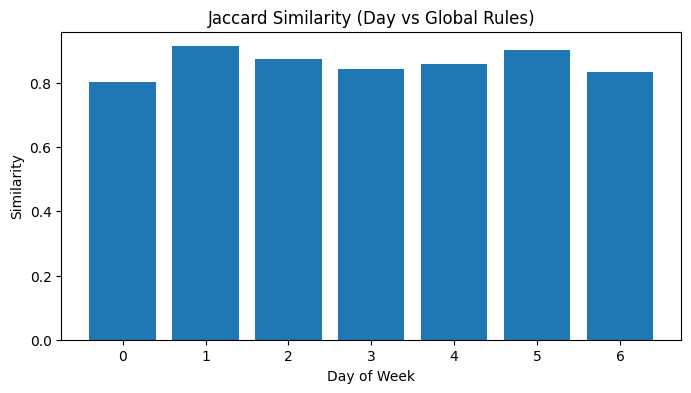


===== Jaccard Similarity: Time Segment vs Global =====
Afternoon: 0.9634
Evening: 0.8787
Morning: 0.9319
Night: 0.8568


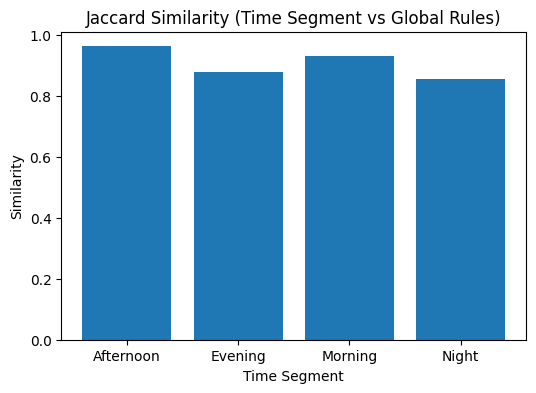

In [62]:
# We compare temporal rule sets with the global rule set using Jaccard similarity to measure overlap.

def rules_to_set(rules_df):
    if rules_df.empty:
        return set()

    return set([
        (tuple(sorted(list(a))), tuple(sorted(list(c))))
        for a, c in zip(rules_df["antecedents"], rules_df["consequents"])
    ])

def jaccard_similarity(set1, set2):
    if len(set1.union(set2)) == 0:
        return 0
    return len(set1.intersection(set2)) / len(set1.union(set2))


# Global Rule Set
global_rule_set = rules_to_set(rules_global)
print(f"\n===== Global Rule Set =====")
print(f"Total rules: {len(global_rule_set)}")

# Day-of-Week Comparison
print(f"\n===== Jaccard Similarity: Day vs Global =====")
day_jaccard = {}
for day in sorted(day_results.keys()):
    day_set = rules_to_set(day_results[day]["rules"])
    sim = jaccard_similarity(global_rule_set, day_set)
    day_jaccard[day] = sim

for day, sim in day_jaccard.items():
    print(f"Day {day}: {sim:.4f}")

# Plot
plt.figure(figsize=(8, 4))
plt.bar(day_jaccard.keys(), day_jaccard.values())
plt.title("Jaccard Similarity (Day vs Global Rules)")
plt.xlabel("Day of Week")
plt.ylabel("Similarity")
plt.show()

# Time-of-Day Comparison
print(f"\n===== Jaccard Similarity: Time Segment vs Global =====")
time_jaccard = {}
for seg in sorted(time_results.keys()):
    seg_set = rules_to_set(time_results[seg]["rules"])
    sim = jaccard_similarity(global_rule_set, seg_set)
    time_jaccard[seg] = sim

for seg, sim in time_jaccard.items():
    print(f"{seg}: {sim:.4f}")

# Plot
plt.figure(figsize=(6, 4))
plt.bar(time_jaccard.keys(), time_jaccard.values())
plt.title("Jaccard Similarity (Time Segment vs Global Rules)")
plt.xlabel("Time Segment")
plt.ylabel("Similarity")
plt.show()

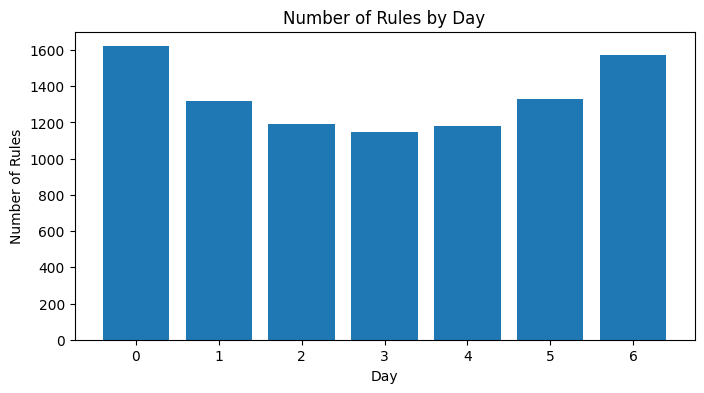

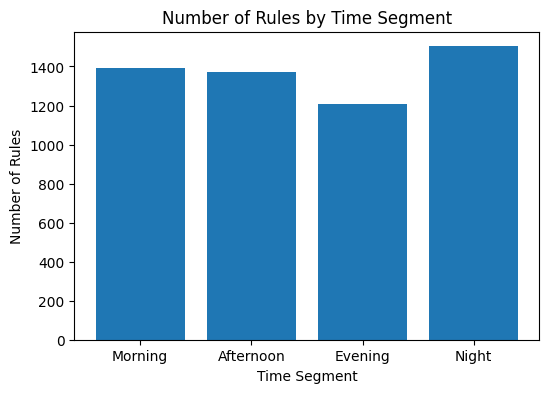

In [63]:
# Rule Count Comparison
# Day rule counts
day_rule_counts = {day: len(res["rules"]) for day, res in day_results.items()}

plt.figure(figsize=(8, 4))
plt.bar(day_rule_counts.keys(), day_rule_counts.values())
plt.title("Number of Rules by Day")
plt.xlabel("Day")
plt.ylabel("Number of Rules")
plt.show()

# Time rule counts
time_rule_counts = {seg: len(res["rules"]) for seg, res in time_results.items()}

plt.figure(figsize=(6, 4))
plt.bar(time_rule_counts.keys(), time_rule_counts.values())
plt.title("Number of Rules by Time Segment")
plt.xlabel("Time Segment")
plt.ylabel("Number of Rules")
plt.show()

In [64]:
# We inspect top rules per time segment to see if any context-specific patterns emerge.

def get_top_rules(rules_df, k=5):
    if rules_df.empty:
        return rules_df
    return rules_df.sort_values(by="lift", ascending=False).head(k)

# Mapping aisle_id → aisle name
aisle_name_map = aisles.set_index("aisle_id")["aisle"].to_dict()

def format_rules_with_names(rules_df):
    if rules_df.empty:
        return rules_df
    
    def convert(itemset):
        return ", ".join([str(aisle_name_map.get(x, x)) for x in sorted(list(itemset))])
    
    temp = rules_df.copy()
    temp["antecedents"] = temp["antecedents"].apply(convert)
    temp["consequents"] = temp["consequents"].apply(convert)
    return temp

# Top Rules per Time Segment
for seg in sorted(time_results.keys()):
    print(f"\n===== Top Rules: {seg} =====")
    
    top_rules = get_top_rules(time_results[seg]["rules"], 5)
    top_rules_named = format_rules_with_names(top_rules)
    
    if top_rules_named.empty:
        print("No rules found")
    else:
        display(top_rules_named)


===== Top Rules: Afternoon =====


,antecedents,consequents,support,confidence,lift
987,pasta sauce,dry pasta,0.021793,0.317267,4.054274
988,dry pasta,pasta sauce,0.021793,0.278488,4.054274
1292,canned jarred vegetables,canned meals beans,0.020377,0.249840,3.251980
1293,canned meals beans,canned jarred vegetables,0.020377,0.265226,3.251980
883,frozen meals,frozen pizza,0.011012,0.137623,2.914232



===== Top Rules: Evening =====


,antecedents,consequents,support,confidence,lift
755,dry pasta,pasta sauce,0.020064,0.276621,4.232392
754,pasta sauce,dry pasta,0.020064,0.306992,4.232392
248,canned meals beans,canned jarred vegetables,0.017383,0.245860,3.424383
247,canned jarred vegetables,canned meals beans,0.017383,0.242109,3.424383
1014,frozen meals,frozen pizza,0.011947,0.139278,2.757461



===== Top Rules: Morning =====


,antecedents,consequents,support,confidence,lift
845,pasta sauce,dry pasta,0.019808,0.315645,4.344141
846,dry pasta,pasta sauce,0.019808,0.272614,4.344141
377,canned jarred vegetables,canned meals beans,0.019639,0.252640,3.488525
378,canned meals beans,canned jarred vegetables,0.019639,0.271187,3.488525
496,frozen appetizers sides,frozen breakfast,0.010330,0.194048,2.880781



===== Top Rules: Night =====


,antecedents,consequents,support,confidence,lift
867,pasta sauce,dry pasta,0.021270,0.310760,3.908340
868,dry pasta,pasta sauce,0.021270,0.267511,3.908340
1460,frozen pizza,frozen meals,0.011183,0.269529,3.249856
1459,frozen meals,frozen pizza,0.011183,0.134835,3.249856
1041,canned jarred vegetables,canned meals beans,0.020102,0.239895,3.032684


In [65]:
# Identify rules that appear only in Morning but not in global patterns

morning_set = rules_to_set(time_results["Morning"]["rules"])
unique_morning = morning_set - global_rule_set

print("\n===== Unique Morning Rules =====")
print(f"Total unique rules: {len(unique_morning)}")

# Convert to readable names
def format_tuple_rule(rule):
    antecedent, consequent = rule
    ant_names = ", ".join([aisle_name_map.get(x, x) for x in antecedent])
    con_names = ", ".join([aisle_name_map.get(x, x) for x in consequent])
    return f"{ant_names} → {con_names}"

# Show top 5
for i, rule in enumerate(list(unique_morning)[:5], 1):
    print(f"{i}. {format_tuple_rule(rule)}")


===== Unique Morning Rules =====
Total unique rules: 63
1. packaged cheese → baking ingredients
2. fresh fruits → nuts seeds dried fruit
3. cream → nuts seeds dried fruit
4. chips pretzels → fruit vegetable snacks
5. breakfast bakery → juice nectars


### Conclusion RQ2

The results show that while many co-purchase patterns remain consistent across time, temporal factors do introduce meaningful variation. High Jaccard similarity values (≈0.85–0.96) indicate that global rules capture the majority of shopping behavior, with core relationships such as pasta sauce ↔ dry pasta and canned vegetables ↔ canned meals beans appearing across all segments.

However, differences in rule counts and the presence of segment-specific rules (e.g., morning-specific patterns like breakfast bakery → juice nectars) highlight that certain associations are context-dependent. These variations suggest that customer purchasing behavior is influenced by when they shop, even if the overall structure remains similar.

Overall, global association rules provide a strong baseline, but temporal segmentation reveals additional patterns that are not captured in aggregate analysis. This indicates that incorporating time-based context can improve the interpretability and usefulness of co-purchase patterns for applications such as targeted recommendations and demand planning.

```
On my honor, I declare the following resources for RQ1:

1. Collaborators:  
- None.

2. Web Sources:  
- Instacart Market Basket Analysis Dataset: https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis  
- Kaggle dataset documentation pages were referenced to understand relational schema and usage constraints.

3. AI Tools:  
- I used chatGPT extensively to provide better readability on the code and visualizations but the overall ideas, questions and prompts provided to the GPT were my own ideas.
- Used some ideas from ChatGPT to generate some EDAs.

4. Conference papers:
- None.
```

## RQ3 Popularity vs Co-occurrence vs Temporal Patterns in Prediction

Main idea:
How well do different recommendation approaches - popularity-based, association rule-based, and sequential transition-based - predict future purchases, and what does this reveal about the importance of popularity, co-occurrence, and temporal patterns?

While RQ1 and RQ2 focused on understanding co-purchase patterns, they do not directly evaluate whether these patterns are useful for predicting what users will buy next. In practice, recommendation systems must go beyond pattern discovery and demonstrate predictive value. A key challenge is distinguishing whether good recommendations come from meaningful relationships between products or simply from the popularity of frequently purchased items. Additionally, user behavior is inherently sequential, and purchases may depend on past actions over time rather than just items in the same basket. Therefore, this question focuses on evaluating the predictive usefulness of different signals and understanding what drives effective recommendations.

Assumptions:
- Users’ past purchase behavior can be used to predict future purchases
- Popular items are likely to appear in many recommendations
- Co-purchase patterns reflect meaningful relationships between items
- Sequential purchase behavior captures temporal dependencies across orders

Why this is my RQ?
- Findings from RQ1 and RQ2 motivate this question:
  - Global co-purchase patterns may be influenced by popularity and parameter choices
  - Temporal variation suggests that behavior is not static
  - Pattern discovery alone does not guarantee predictive usefulness

Thus, it is important to evaluate whether these patterns actually improve recommendation quality and which type of signal (popularity, co-occurrence, or temporal behavior) is most useful.

Sub-questions
- How does a popularity-based baseline perform in predicting future purchases?
- Do association rule-based recommendations improve over popularity?
- Does incorporating sequential (temporal) behavior further improve prediction?
- Which approach generates more accurate and relevant recommendations?

Additional EDA under RQ3
- Distribution of product popularity (frequency of purchases)
- Reorder behavior across users
- Basket size distribution for prediction tasks
- Coverage of rules and transitions across products

Methods
- Split user data into training (past baskets) and test (next basket)
- Build three recommendation approaches:
  - Popularity-based recommender (top frequent products)
  - Association rule-based recommender (FP-Growth + rules)
  - Sequential transition-based recommender (product-to-product transitions across orders)
- Generate top-K recommendations for each user
- Compare predicted items with actual next-basket purchases

Expected Outputs
- Precision@K and Recall@K for each method
- Comparison of performance across models
- Example user-level recommendation comparisons
- Analysis of recommendation coverage (users with/without recommendations)
- Insights into the relative importance of popularity, co-occurrence, and temporal signals

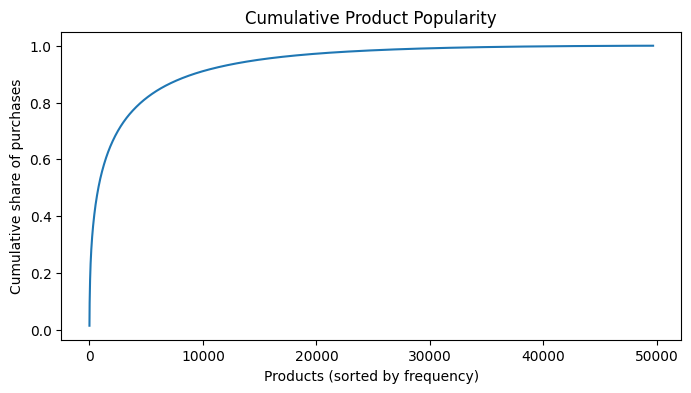

Top 1% products cover ~42.80% of purchases
Top 5% products cover ~69.85% of purchases
Top 10% products cover ~81.43% of purchases


In [66]:
# Supporting EDA
# Product popularity distribution
product_freq = order_products_prior["product_id"].value_counts().sort_values(ascending=False)
cum_pop = product_freq.cumsum() / product_freq.sum()

plt.figure(figsize=(8, 4))
plt.plot(cum_pop.values)
plt.title("Cumulative Product Popularity")
plt.xlabel("Products (sorted by frequency)")
plt.ylabel("Cumulative share of purchases")
plt.show()

n = len(product_freq)
print(f"Top 1% products cover ~{cum_pop.iloc[int(0.01*n)]:.2%} of purchases")
print(f"Top 5% products cover ~{cum_pop.iloc[int(0.05*n)]:.2%} of purchases")
print(f"Top 10% products cover ~{cum_pop.iloc[int(0.10*n)]:.2%} of purchases")

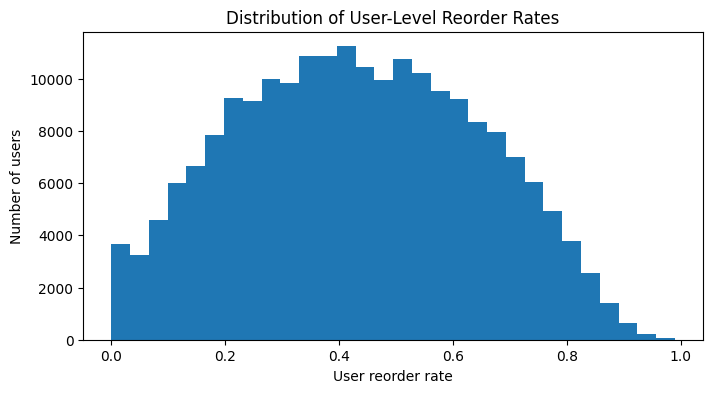

Overall reorder rate: 58.97%
count    206209.000000
mean          0.432249
std           0.212144
min           0.000000
25%           0.267857
50%           0.428571
75%           0.595745
max           0.989529
Name: reordered, dtype: float64


In [67]:
# Reorder behavior summary
reorder_rate = order_products_prior["reordered"].mean()
user_reorder_rate = (order_products_prior.groupby("user_id")["reordered"].mean())

plt.figure(figsize=(8, 4))
plt.hist(user_reorder_rate, bins=30)
plt.title("Distribution of User-Level Reorder Rates")
plt.xlabel("User reorder rate")
plt.ylabel("Number of users")
plt.show()

print(f"Overall reorder rate: {reorder_rate:.2%}")
print(user_reorder_rate.describe())

The product popularity distribution is highly skewed, with a small fraction of products accounting for a large share of purchases. This suggests that a simple popularity-based approach may already perform well, making it a strong baseline for comparison. At the same time, high reorder rates indicate that many purchases are habitual. This motivates including a sequential baseline, as future purchases may depend on recent buying behavior in addition to overall popularity or co-occurrence patterns.

In [68]:
# Next, we split user order history into train and test sets 
# so we can evaluate how well different methods predict future purchases.

# Build per-user prior orders
# Keep only prior orders and order them correctly
prior_orders = orders[orders["eval_set"] == "prior"].copy()
prior_orders = prior_orders.sort_values(["user_id", "order_number"])

print("Total prior orders:", len(prior_orders))
print("Users with prior orders:", prior_orders["user_id"].nunique())
prior_orders.head()

# Split into train and test orders
# Last prior order per user = test
test_orders = prior_orders.groupby("user_id").tail(1).copy()
# All earlier prior orders = train
train_orders = prior_orders.drop(test_orders.index).copy()

print("Train orders:", len(train_orders))
print("Test orders:", len(test_orders))
print("Unique users in test:", test_orders["user_id"].nunique())

# Keep only users with at least 2 prior orders
user_order_counts = prior_orders.groupby("user_id").size()
valid_users = user_order_counts[user_order_counts >= 2].index
train_orders = train_orders[train_orders["user_id"].isin(valid_users)].copy()
test_orders = test_orders[test_orders["user_id"].isin(valid_users)].copy()

print("Valid users:", len(valid_users))
print("Filtered train orders:", len(train_orders))
print("Filtered test orders:", len(test_orders))

Total prior orders: 3214874
Users with prior orders: 206209
Train orders: 3008665
Test orders: 206209
Unique users in test: 206209
Valid users: 206209
Filtered train orders: 3008665
Filtered test orders: 206209


In [69]:
# We now construct train and test baskets 
# so we can compare predicted items against actual future purchases.

# Build Train/Test Basket Dictionaries
# Training baskets by order
train_baskets = (
    order_products_prior[order_products_prior["order_id"].isin(train_orders["order_id"])]
    .groupby("order_id")["product_id"]
    .apply(lambda x: sorted(set(x)))
)

# Test baskets by order
test_baskets = (
    order_products_prior[order_products_prior["order_id"].isin(test_orders["order_id"])]
    .groupby("order_id")["product_id"]
    .apply(lambda x: sorted(set(x)))
)

print("===== Basket Summary =====")
print(f"Train basket count: {len(train_baskets)}")
print(f"Test basket count: {len(test_baskets)}")

===== Basket Summary =====
Train basket count: 3008665
Test basket count: 206209


In [70]:
# We now prepare the input-output pairs needed for prediction 
# Each user’s last training basket is used to predict their next basket.

# user -> test order id
user_test_order = test_orders.set_index("user_id")["order_id"].to_dict()

# user -> test basket
user_test_basket = {user: set(test_baskets.get(order_id, [])) for user, order_id in user_test_order.items()}

# Keep only users with non-empty test baskets
user_test_basket = {user: basket for user, basket in user_test_basket.items() if len(basket) > 0}
print("Users with non-empty test baskets:", len(user_test_basket))

# Last training order per user
last_train_orders = (train_orders.sort_values(["user_id", "order_number"]).groupby("user_id").tail(1).copy())

# user -> last train order id
user_last_train_order = last_train_orders.set_index("user_id")["order_id"].to_dict()

# user -> last train basket
user_last_train_basket = {user: set(train_baskets.get(order_id, [])) 
                          for user, order_id in user_last_train_order.items()}

# Keep only users that appear in both train-input and test-target sets
common_users = set(user_last_train_basket.keys()).intersection(user_test_basket.keys())

user_last_train_basket = {user: user_last_train_basket[user]
                          for user in common_users if len(user_last_train_basket[user]) > 0}
user_test_basket = {user: user_test_basket[user] for user in common_users}

print("Users with both train-input and test-target baskets:", len(common_users))

Users with non-empty test baskets: 206209
Users with both train-input and test-target baskets: 206209


To evaluate predictive utility, I treated each user’s last prior order as the test target and use all earlier prior orders for training. The user’s most recent training basket is then used as the input for prediction. This setup mimics a realistic next-order prediction task and avoids leakage from future purchases into the training data.


===== Top-K Products with Popularity =====


,product_name,count
0,Banana,443151
1,Bag of Organic Bananas,355357
2,Organic Strawberries,249093
3,Organic Baby Spinach,226511
4,Organic Hass Avocado,202023
5,Organic Avocado,165270
6,Large Lemon,140557
7,Strawberries,132939
8,Limes,131440
9,Organic Whole Milk,130239


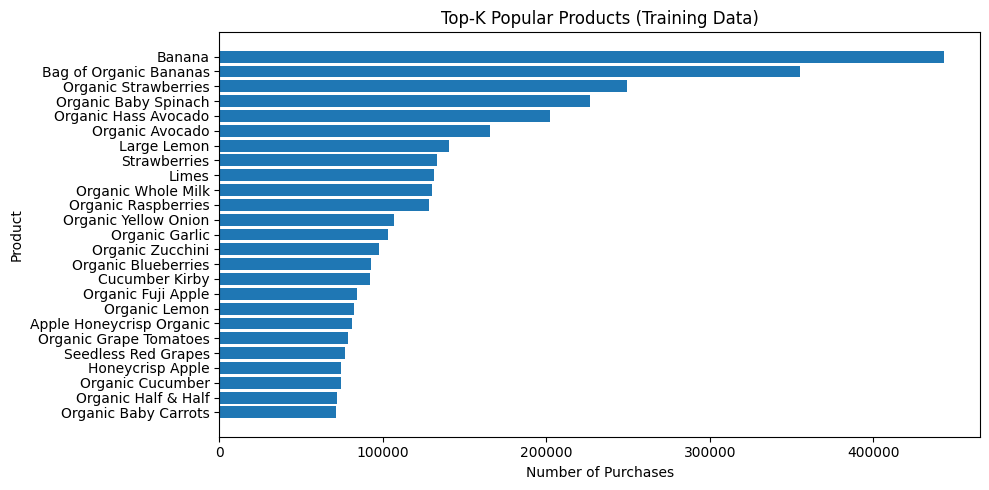


Total users with popularity recommendations: 206209


In [71]:
# We build a popularity baseline by selecting the most frequently purchased products in training data 
# and use it as a simple recommendation benchmark.

K = 25
train_product_data = order_products_prior[
    order_products_prior["order_id"].isin(train_orders["order_id"])
].copy()

# Compute popularity (frequency)
product_popularity = train_product_data["product_id"].value_counts()

top_k_products = product_popularity.head(K).index.tolist()

# Test checks
assert len(top_k_products) == K, "Top-K products not computed correctly"
assert product_popularity.iloc[0] >= product_popularity.iloc[-1], "Popularity not sorted correctly"

# Map product IDs to names + show counts
product_name_map = products.set_index("product_id")["product_name"].to_dict()

top_k_df = product_popularity.head(K).reset_index()
top_k_df.columns = ["product_id", "count"]
top_k_df["product_name"] = top_k_df["product_id"].map(product_name_map)

print("\n===== Top-K Products with Popularity =====")
display(top_k_df[["product_name", "count"]])


# Visualization
plt.figure(figsize=(10, 5))
plt.barh(top_k_df["product_name"], top_k_df["count"])
plt.gca().invert_yaxis()
plt.title("Top-K Popular Products (Training Data)")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# Popularity recommendations
popularity_recs = {user: set(top_k_products) for user in user_last_train_basket.keys()}

print("\nTotal users with popularity recommendations:", len(popularity_recs))

In [72]:
# We now build the training baskets for rule mining by restricting to the most frequent products, 
# which keeps the model tractable while focusing on items most likely to form stable rules.

# Association Rule Recommender
# We learn rules from training baskets only, then recommend consequents based on the user’s 
# last training basket.

# Restrict product universe for rule mining
top_n_rule_products = 300
top_rule_products = (train_product_data["product_id"].value_counts().head(top_n_rule_products).index)

# Keep only top products in training orders
train_product_data_top = train_product_data[
    train_product_data["product_id"].isin(top_rule_products)
].copy()

# Build filtered training baskets for rule mining
train_baskets_top = (
    train_product_data_top.groupby("order_id")["product_id"]
    .apply(lambda x: sorted(set(x)))
)

# Keep only baskets with at least 2 retained products
train_baskets_top = train_baskets_top[train_baskets_top.apply(len) >= 2]

# checks
assert len(top_rule_products) == top_n_rule_products, "Top rule-product set was not created correctly"
assert (train_baskets_top.apply(len) >= 2).all(), "Some retained baskets have fewer than 2 products"

print("===== Rule Mining Input Summary =====")
print(f"Top rule-mining products retained: {len(top_rule_products)}")
print(f"Filtered training baskets for rule mining: {len(train_baskets_top)}")

===== Rule Mining Input Summary =====
Top rule-mining products retained: 300
Filtered training baskets for rule mining: 1973972


In [73]:
# We now mine product-level association rules from the filtered training baskets 
# so they can be used as one recommendation method in the prediction task.

train_transactions = train_baskets_top.tolist()
print("Filtered training baskets for rule mining:", len(train_transactions))
print("Retained products for rule mining:", len(top_rule_products))

coverage = train_product_data["product_id"].isin(top_rule_products).mean()
print(f"Top {top_n_rule_products} products account for {coverage:.2%} of training interactions")

te = TransactionEncoder()
train_te_array = te.fit(train_transactions).transform(train_transactions)
df_train_rules = pd.DataFrame(train_te_array, columns=te.columns_)

# Meaningful checks
assert len(train_transactions) == len(train_baskets_top), "Transaction list size does not match filtered baskets"
assert df_train_rules.shape[1] <= top_n_rule_products, "Rule matrix has more products than expected"

print("Training rule matrix shape:", df_train_rules.shape)

# Mine product-level rules on training data
min_support_rq3 = 0.01

frequent_items_rq3 = fpgrowth(
    df_train_rules,
    min_support=min_support_rq3,
    use_colnames=True,
    max_len=2
)

frequent_items_rq3["itemset_size"] = frequent_items_rq3["itemsets"].apply(len)

rules_rq3 = association_rules(
    frequent_items_rq3,
    metric="confidence",
    min_threshold=0.1
)

if not rules_rq3.empty:
    rules_rq3 = rules_rq3[
        ["antecedents", "consequents", "support", "confidence", "lift"]
    ].copy()

    assert set(rules_rq3.columns) == {"antecedents", "consequents", "support", "confidence", "lift"}, "Unexpected rule columns"

print("Frequent itemsets:", len(frequent_items_rq3))
print("Rules:", len(rules_rq3))

# Map product IDs to names for readability
product_name_map = products.set_index("product_id")["product_name"].to_dict()

def convert_itemset(itemset):
    return ", ".join([str(product_name_map.get(x, x)) for x in sorted(list(itemset))])

rules_rq3_named = rules_rq3.copy()
if not rules_rq3_named.empty:
    rules_rq3_named["antecedents"] = rules_rq3_named["antecedents"].apply(convert_itemset)
    rules_rq3_named["consequents"] = rules_rq3_named["consequents"].apply(convert_itemset)

print("\nSample rules with product names:")
display(rules_rq3_named.head())

Filtered training baskets for rule mining: 1973972
Retained products for rule mining: 300
Top 300 products account for 35.76% of training interactions
Training rule matrix shape: (1973972, 300)
Frequent itemsets: 203
Rules: 60

Sample rules with product names:


,antecedents,consequents,support,confidence,lift
0,Banana,Organic Baby Spinach,0.024457,0.117589,1.061698
1,Organic Baby Spinach,Banana,0.024457,0.220817,1.061698
2,Organic Strawberries,Organic Baby Spinach,0.018118,0.148931,1.344678
3,Organic Baby Spinach,Organic Strawberries,0.018118,0.163583,1.344678
4,Bag of Organic Bananas,Organic Baby Spinach,0.023730,0.141635,1.278801


Direct rule mining over the full product space is not computationally feasible for the Instacart dataset on standard hardware. To keep the rule-based recommender tractable, we restrict mining to the most frequent training products, since rare products are unlikely to generate stable pairwise rules at the chosen support threshold. We observe that product popularity is highly skewed, with items like bananas and organic bananas appearing far more frequently than others. By restricting rule mining to the top 300 products, we still cover over 35% of all training interactions, while keeping computation manageable. Even with this reduced set, we learn meaningful patterns (203 itemsets and 60 rules), showing that this simplification is sufficient for evaluating whether association rules add value beyond popularity in RQ3.

In [74]:
# We convert the learned rules into a simple product-to-product lookup table that can be used for 
# recommendation.

# Build antecedent → ranked consequents map
# Restrict to singleton antecedent and singleton consequent for clean recommendation logic
pair_rules_rq3 = rules_rq3[
    (rules_rq3["antecedents"].apply(len) == 1) &
    (rules_rq3["consequents"].apply(len) == 1)
].copy()

# Sort by lift, then confidence, then support
pair_rules_rq3 = pair_rules_rq3.sort_values(
    by=["lift", "confidence", "support"],
    ascending=False
)

# Build rule lookup: antecedent product -> ranked list of consequent products
rule_map = {}

for _, row in pair_rules_rq3.iterrows():
    ant = list(row["antecedents"])[0]
    cons = list(row["consequents"])[0]

    rule_map.setdefault(ant, [])
    if cons not in rule_map[ant]:
        rule_map[ant].append(cons)

# Meaningful checks
assert len(pair_rules_rq3) <= len(rules_rq3), "Filtered pair rules exceed total rules"
assert len(rule_map) > 0, "No rule mappings were learned"

print("===== Pairwise Rule Mapping Summary =====")
print(f"Total pairwise rules: {len(pair_rules_rq3)}")
print(f"Antecedent products with learned rules: {len(rule_map)}")

===== Pairwise Rule Mapping Summary =====
Total pairwise rules: 60
Antecedent products with learned rules: 23


In [75]:
# We check how many products actually have learned rules and look at a few example product-to-product recommendations.

total_products = len(top_rule_products)
covered_products = len(rule_map)

print("===== Rule Coverage Summary =====")
print(f"Products used for rule mining: {total_products}")
print(f"Products with at least one rule: {covered_products}")
print(f"Coverage: {covered_products / total_products:.2%}")

print("\n===== Sample Learned Rules (Antecedent → Consequents) =====")

sample_items = list(rule_map.keys())[:5]

for ant in sample_items:
    ant_name = product_name_map.get(ant, ant)
    cons_names = [product_name_map.get(c, c) for c in rule_map[ant][:3]]
    print(f"{ant_name} → {', '.join(cons_names)}")

===== Rule Coverage Summary =====
Products used for rule mining: 300
Products with at least one rule: 23
Coverage: 7.67%

===== Sample Learned Rules (Antecedent → Consequents) =====
Organic Garlic → Organic Yellow Onion, Bag of Organic Bananas
Organic Yellow Onion → Organic Garlic, Bag of Organic Bananas
Limes → Large Lemon, Organic Avocado, Banana
Large Lemon → Limes, Organic Avocado, Organic Baby Spinach
Organic Lemon → Organic Hass Avocado, Bag of Organic Bananas


In [76]:
# We generate rule-based recommendations using association rules learned from training baskets 
# to evaluate how well co-purchase patterns can predict future user purchases (RQ3).

# Generate rule-based recommendations
def recommend_from_rules(input_basket, rule_map, k=10):
    recs = []
    seen = set(input_basket)

    for item in input_basket:
        for candidate in rule_map.get(item, []):
            if candidate not in seen and candidate not in recs:
                recs.append(candidate)
            if len(recs) >= k:
                return set(recs)

    return set(recs[:k])


# Generate recommendations for all users
rule_recs = {
    user: recommend_from_rules(user_last_train_basket[user], rule_map, k=K)
    for user in user_last_train_basket.keys()
}

# Summary + Debug Prints
print("===== Rule-based Recommendation Summary =====")

num_users = len(rule_recs)
avg_recs = sum(len(r) for r in rule_recs.values()) / num_users

print(f"Total users evaluated: {num_users}")
print(f"Average recommendations per user: {avg_recs:.2f}")
print(f"Max recommendations: {max(len(r) for r in rule_recs.values())}")
print(f"Min recommendations: {min(len(r) for r in rule_recs.values())}")
print("\n===== Sample User Recommendations =====")

sample_users = list(rule_recs.keys())[:5]

for user in sample_users:
    input_items = user_last_train_basket[user]
    rec_items = rule_recs[user]

    print(f"\nUser: {user}")
    print(f"  Input basket size: {len(input_items)}")
    print(f"  Recommendations generated: {len(rec_items)}")

    # Map to product names if available
    input_names = [product_name_map.get(i, str(i)) for i in input_items]
    rec_names = [product_name_map.get(i, str(i)) for i in rec_items]

    print(f"  Input items (sample): {input_names[:5]}")
    print(f"  Recommended items (sample): {rec_names[:5]}")


zero_rec_users = sum(1 for r in rule_recs.values() if len(r) == 0)
print(f"\nUsers with NO recommendations: {zero_rec_users} ({zero_rec_users/num_users:.2%})")

===== Rule-based Recommendation Summary =====
Total users evaluated: 206209
Average recommendations per user: 2.13
Max recommendations: 9
Min recommendations: 0

===== Sample User Recommendations =====

User: 1
  Input basket size: 6
  Recommendations generated: 0
  Input items (sample): ['Soda', 'Zero Calorie Cola', 'Original Beef Jerky', 'Organic String Cheese', 'Pistachios']
  Recommended items (sample): []

User: 2
  Input basket size: 9
  Recommendations generated: 1
  Input items (sample): ['Organic Granny Smith Apple', 'Roasted Turkey Breast', 'Gluten Free 7 Grain Bread', 'Walnut Halves & Pieces', 'Unsweetened Carob Chips']
  Recommended items (sample): ['Bag of Organic Bananas']

User: 3
  Input basket size: 5
  Recommendations generated: 6
  Input items (sample): ['Unsweetened Chocolate Almond Breeze Almond Milk', 'Organic Baby Spinach', 'Organic Avocado', 'Vanilla Unsweetened Almond Milk', 'Organic Peeled Whole Baby Carrots']
  Recommended items (sample): ['Limes', 'Organic H

The rule-based recommender shows limited coverage. Although we mined rules from the top 300 products, only 23 products (7.67%) have at least one rule, which significantly restricts recommendation generation. As a result, nearly 47% of users receive no recommendations at all. This happens because association rules require sufficient co-occurrence support. Many products, especially less frequent ones, do not appear often enough in strong itemsets to form rules. Even for users with larger baskets, if their items are not part of the learned rule set, no recommendations can be generated. This highlights a key limitation of rule-based approaches and it is that they struggle with sparsity and limited coverage, making them less reliable for broad recommendation tasks.

In [77]:
# In this step, we model sequential purchase behavior by learning product-to-product
# transitions across consecutive orders. This helps us capture temporal purchase
# patterns beyond simple co-occurrence and supports our RQ3 recommendation analysis.

from collections import defaultdict, Counter

# order_id -> basket of unique products
all_prior_baskets = (
    order_products_prior.groupby("order_id")["product_id"]
    .apply(lambda x: sorted(set(x)))
    .to_dict()
)

# user -> ordered list of prior order_ids
user_order_sequences = (
    prior_orders[prior_orders["user_id"].isin(common_users)]
    .sort_values(["user_id", "order_number"])
    .groupby("user_id")["order_id"]
    .apply(list)
)

# Learn product-to-next-order transitions
transition_counts = defaultdict(Counter)

for user, order_ids in user_order_sequences.items():
    # Need at least 2 orders to observe transitions
    if len(order_ids) < 2:
        continue

    for i in range(len(order_ids) - 1):
        current_order = set(all_prior_baskets.get(order_ids[i], []))
        next_order = set(all_prior_baskets.get(order_ids[i + 1], []))

        for item in current_order:
            for next_item in next_order:
                if next_item != item:
                    transition_counts[item][next_item] += 1

# Build transition recommendation map
transition_map = {}

for item, counter in transition_counts.items():
    ranked = [next_item for next_item, _ in counter.most_common()]
    transition_map[item] = ranked

print("===== Sequential Transition Model Summary =====")
print(f"Total unique products with observed transitions: {len(transition_counts)}")
print("These are products for which we observed at least one transition to a product in a later order.")

print(f"\nTotal products stored in the transition map: {len(transition_map)}")
print("For each of these products, we keep a ranked list of likely next products based on transition frequency.")

total_transitions = sum(sum(counter.values()) for counter in transition_counts.values())
print(f"\nTotal product-to-product transitions learned: {total_transitions}")
print("This counts all observed transitions across consecutive orders for all users.")

print("\n===== Sample Learned Transitions =====")
sample_items = list(transition_map.keys())[:5]

for item in sample_items:
    item_name = product_name_map.get(item, f"Product {item}")
    top_next_items = transition_map[item][:5]
    top_next_names = [product_name_map.get(x, f"Product {x}") for x in top_next_items]

    print(f"\nCurrent product: {item_name}")
    print(f"Top likely next products: {top_next_names}")

===== Sequential Transition Model Summary =====
Total unique products with observed transitions: 49652
These are products for which we observed at least one transition to a product in a later order.

Total products stored in the transition map: 49652
For each of these products, we keep a ranked list of likely next products based on transition frequency.

Total product-to-product transitions learned: 395578348
This counts all observed transitions across consecutive orders for all users.

===== Sample Learned Transitions =====

Current product: Soda
Top likely next products: ['Clementines', 'Bag of Organic Bananas', '0% Greek Strained Yogurt', 'Zero Calorie Cola', 'Trail Mix']

Current product: XL Pick-A-Size Paper Towel Rolls
Top likely next products: ['Bag of Organic Bananas', 'Raspberries', 'Hass Avocados', 'Soda', 'Clementines']

Current product: Organic Unsweetened Vanilla Almond Milk
Top likely next products: ['Bag of Organic Bananas', 'Organic Baby Spinach', 'Banana', 'Organic Str

The sequential transition model shows significantly higher coverage compared to the rule-based approach. We learn transitions for 49,652 products, covering almost the entire product space, with over 395 million observed transitions. As a result, this method can generate recommendations for a much larger portion of users. However, many of the learned transitions are still dominated by highly popular items such as bag of organic bananas, strawberries, and spinach. This suggests that while the sequential model captures temporal behavior, it is still influenced by product popularity. The key advantage of this approach is its high coverage and ability to generate recommendations consistently.

In [78]:
# In this step, we generate sequence-aware recommendations using the learned
# product transition patterns, allowing us to predict what a user is likely
# to purchase next based on their most recent basket (RQ3).

# Generate sequential recommendations
def recommend_from_transitions(input_basket, transition_map, k=10):
    recs = []
    seen = set(input_basket)

    for item in input_basket:
        for candidate in transition_map.get(item, []):
            if candidate not in seen and candidate not in recs:
                recs.append(candidate)
            if len(recs) >= k:
                return set(recs)

    return set(recs[:k])


# Generate recommendations for all users
sequential_recs = {
    user: recommend_from_transitions(user_last_train_basket[user], transition_map, k=K)
    for user in user_last_train_basket.keys()
}

# Summary + Debug Prints
print("===== Sequential Recommendation Summary =====")

num_users = len(sequential_recs)
avg_recs = sum(len(r) for r in sequential_recs.values()) / num_users

print(f"Total users evaluated: {num_users}")
print(f"Average recommendations per user: {avg_recs:.2f}")
print(f"Max recommendations: {max(len(r) for r in sequential_recs.values())}")
print(f"Min recommendations: {min(len(r) for r in sequential_recs.values())}")

# Users with no recommendations (important insight)
zero_rec_users = sum(1 for r in sequential_recs.values() if len(r) == 0)
print(f"Users with NO recommendations: {zero_rec_users} ({zero_rec_users/num_users:.2%})")


print("\n===== Sample Sequential Recommendations =====")

sample_users = list(sequential_recs.keys())[:5]

for user in sample_users:
    input_items = user_last_train_basket[user]
    rec_items = sequential_recs[user]

    print(f"\nUser: {user}")
    print(f"  Input basket size: {len(input_items)}")
    print(f"  Recommendations generated: {len(rec_items)}")

    input_names = [product_name_map.get(i, str(i)) for i in input_items]
    rec_names = [product_name_map.get(i, str(i)) for i in rec_items]

    print(f"  Input items (sample): {input_names[:5]}")
    print(f"  Recommended items (sample): {rec_names[:5]}")

===== Sequential Recommendation Summary =====
Total users evaluated: 206209
Average recommendations per user: 25.00
Max recommendations: 25
Min recommendations: 3
Users with NO recommendations: 0 (0.00%)

===== Sample Sequential Recommendations =====

User: 1
  Input basket size: 6
  Recommendations generated: 25
  Input items (sample): ['Soda', 'Zero Calorie Cola', 'Original Beef Jerky', 'Organic String Cheese', 'Pistachios']
  Recommended items (sample): ['Apples', 'Chocolate Chip Cookies', 'Cherrios Honey Nut', '0% Greek Strained Yogurt', 'Sparkling Mineral Water']

User: 2
  Input basket size: 9
  Recommendations generated: 25
  Input items (sample): ['Organic Granny Smith Apple', 'Roasted Turkey Breast', 'Gluten Free 7 Grain Bread', 'Walnut Halves & Pieces', 'Unsweetened Carob Chips']
  Recommended items (sample): ['Organic Grape Tomatoes', 'Organic Garlic', 'Large Lemon', 'Organic Gala Apples', 'Organic Baby Spinach']

User: 3
  Input basket size: 5
  Recommendations generated: 2

In [79]:
# Evaluation
# We now compare all three methods using Precision@K and Recall@K.
# Evaluation functions

def precision_at_k(recommended, actual, k):
    if k == 0:
        return 0.0
    return len(recommended.intersection(actual)) / k

def recall_at_k(recommended, actual):
    if len(actual) == 0:
        return 0.0
    return len(recommended.intersection(actual)) / len(actual)

def evaluate_recommender(recs_dict, actual_dict, k=10):
    precisions = []
    recalls = []

    for user in actual_dict.keys():
        recs = recs_dict.get(user, set())
        actual = actual_dict[user]

        precisions.append(precision_at_k(recs, actual, k))
        recalls.append(recall_at_k(recs, actual))

    return {
        "Precision@K": np.mean(precisions),
        "Recall@K": np.mean(recalls)
    }

# Evaluate all methods
results_rq3 = pd.DataFrame([
    {
        "Method": "Popularity",
        **evaluate_recommender(popularity_recs, user_test_basket, k=K)
    },
    {
        "Method": "Association Rules",
        **evaluate_recommender(rule_recs, user_test_basket, k=K)
    },
    {
        "Method": "Sequential Transitions",
        **evaluate_recommender(sequential_recs, user_test_basket, k=K)
    }
])

results_rq3

,Method,Precision@K,Recall@K
0,Popularity,0.045646,0.107918
1,Association Rules,0.006119,0.012889
2,Sequential Transitions,0.033357,0.084744


In [80]:
# Product name lookup
product_name_map = products.set_index("product_id")["product_name"].to_dict()

print("===== Example User Recommendation Comparison =====")
print("We compare different recommendation strategies for a sample user to understand how each method behaves (RQ3).")

# Pick a sample user
sample_user = list(common_users)[0]

# Fetch data
input_items = user_last_train_basket[sample_user]
actual_items = user_test_basket[sample_user]
pop_recs = popularity_recs[sample_user]
rule_recs_user = rule_recs[sample_user]
seq_recs = sequential_recs[sample_user]

# Convert to names
input_names = [product_name_map.get(x, str(x)) for x in sorted(input_items)]
actual_names = [product_name_map.get(x, str(x)) for x in sorted(actual_items)]
pop_names = [product_name_map.get(x, str(x)) for x in sorted(pop_recs)]
rule_names = [product_name_map.get(x, str(x)) for x in sorted(rule_recs_user)]
seq_names = [product_name_map.get(x, str(x)) for x in sorted(seq_recs)]

# Print nicely
print(f"\nUser ID: {sample_user}")

print("\n--- Input (Last Training Basket) ---")
print(f"Items ({len(input_names)}): {input_names}")

print("\n--- Actual Next Basket (Ground Truth) ---")
print(f"Items ({len(actual_names)}): {actual_names}")

print("\n--- Popularity-Based Recommendations ---")
print(f"Items ({len(pop_names)}): {pop_names}")

print("\n--- Rule-Based Recommendations (Co-occurrence) ---")
print(f"Items ({len(rule_names)}): {rule_names}")

print("\n--- Sequential Recommendations (Temporal) ---")
print(f"Items ({len(seq_names)}): {seq_names}")

===== Example User Recommendation Comparison =====
We compare different recommendation strategies for a sample user to understand how each method behaves (RQ3).

User ID: 1

--- Input (Last Training Basket) ---
Items (6): ['Soda', 'Pistachios', 'Original Beef Jerky', 'Organic String Cheese', 'Zero Calorie Cola', 'Organic Half & Half']

--- Actual Next Basket (Ground Truth) ---
Items (9): ['Soda', 'Pistachios', 'Original Beef Jerky', 'Cinnamon Toast Crunch', 'Organic String Cheese', 'Organic Unsweetened Almond Milk', '0% Greek Strained Yogurt', 'Milk Chocolate Almonds', 'Zero Calorie Cola']

--- Popularity-Based Recommendations ---
Items (25): ['Seedless Red Grapes', 'Organic Lemon', 'Apple Honeycrisp Organic', 'Bag of Organic Bananas', 'Strawberries', 'Organic Strawberries', 'Organic Baby Spinach', 'Organic Yellow Onion', 'Banana', 'Organic Garlic', 'Limes', 'Organic Whole Milk', 'Organic Raspberries', 'Organic Fuji Apple', 'Organic Cucumber', 'Organic Blueberries', 'Organic Grape Toma

For this example user, the popularity-based recommender suggests many common items but has limited overlap with the actual next basket. The rule-based method fails to generate any recommendations, highlighting its low coverage issue. In contrast, the sequential model produces relevant recommendations such as 0% Greek yogurt and milk chocolate almonds, which actually appear in the user’s next basket. This shows that sequential patterns can better capture user-specific behavior over time.

This example shows that while popularity provides generic suggestions, sequential models are more effective in capturing personalized and temporal purchase patterns, whereas rule-based methods may fail due to sparsity.

### Conlcusion RQ3

In RQ3, we compare three approaches for predicting next purchases: popularity-based, rule-based, and sequential transition-based recommenders.

The popularity baseline captures global trends and performs reasonably well because the dataset is highly skewed toward a few frequent items (e.g., bananas, strawberries). The rule-based method attempts to use co-purchase relationships, but its effectiveness is limited due to low coverage—only 23 out of 300 products (7.67%) form rules, and nearly 47% of users receive no recommendations. This shows that association rules struggle with sparsity and cannot generalize well across users.

In contrast, the sequential transition model achieves much higher coverage, learning transitions for ~49K products with over 395M transitions, allowing it to generate recommendations for most users. However, many recommendations are still influenced by popular items, indicating that popularity remains a strong underlying factor.

Overall, the results show that:
- Popularity is a strong baseline due to data skew
- Association rules capture meaningful relationships but suffer from low coverage
- Sequential models improve coverage and incorporate temporal behavior

My understanding is that, temporal information improves recommendation coverage and usefulness, but popularity still plays a dominant role.

```
On my honor, I declare the following resources for RQ1:

1. Collaborators:  
- None.

2. Web Sources:  
- None.

3. AI Tools:  
- I used chatGPT extensively to provide better readability on the code and visualizations but the overall ideas, questions and prompts provided to the GPT were my own ideas.
- I also used ChatGPT to learn about some topics and ideas which I implemented in this checkpoint.

4. Conference papers:
- None.
```

## Research Question to Method Mapping

This table summarizes how each research question maps to specific data mining tasks, algorithms, and evaluation strategies used in the project.

| RQ | Data Mining Task | Course Techniques | External Techniques | Evaluation Metrics |
|----|----------------|------------------|---------------------|--------------------|
| **RQ1: Stability of association rules** | Frequent itemset mining & rule generation | FP-Growth, Association Rules (support, confidence, lift) | — | Number of rules, stability across thresholds (Jaccard similarity), interpretability |
| **RQ2: Temporal variation in co-purchase patterns** | Pattern mining across segments | FP-Growth, Association Rules | — | Rule count comparison, Jaccard similarity vs global rules, top-rule differences |
| **RQ3: Popularity vs meaningful relationships & prediction** | Recommendation / predictive modeling | Association Rules | Sequential transition modeling (external) | Precision@K, Recall@K |

## Final Summary

This project studies how useful association rules are for understanding and predicting customer purchase behavior in the Instacart dataset. The analysis is structured into three research questions that move from pattern discovery to practical evaluation.

- For RQ1, we analyze how stable association rules are under different support thresholds and representations (product vs aisle level). Using FP-Growth, we observe that rule discovery is sensitive to parameter choices, and while some patterns remain stable, many change depending on how the data is represented. This shows that association rules are not always robust.
- For RQ2, we explore how co-purchase patterns vary across time (day of week and time of day). By segmenting the data and mining rules within each segment, we find that shopping behavior changes across contexts. This suggests that global rules may hide important temporal variations and that customer behavior is not uniform.
- For RQ3, we evaluate whether these patterns are actually useful for prediction. We compare three approaches:
  - A popularity-based baseline
  - A rule-based recommender
  - A sequential transition-based model

The results show that popularity is a strong baseline due to the skewed nature of the data. The rule-based method captures meaningful relationships but suffers from low coverage, with only 7.67% of products forming rules and nearly 47% of users receiving no recommendations. In contrast, the sequential model achieves much higher coverage (over 49K products and 395M transitions) and generates recommendations for most users, although it is still influenced by popular items.

Overall, the project shows that:
- Association rules can capture useful patterns but are sensitive and sparse
- Temporal segmentation reveals important variations in behavior
- Sequential models improve coverage and prediction but do not fully overcome popularity bias

Link: https://github.com/sumanthreddy07/InstaCart-Online-Grocery-Basket-Analysis/

Link to the notebook is inside the Notebooks folder

```
On my honor, I declare the following resources for RQ1:

1. Collaborators:  
- None.

2. Web Sources:  
- None.

3. AI Tools:  
- I used chatGPT to provide better readability on the final writeup.

4. Conference papers:
- None.
```